In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Paste your copied path between the quotes
#file_path = '/content/drive/MyDrive/Final project/task_level_eeg_features.csv' #Create Final project folder in own drive and upload data there

#full_data = pd.read_csv(file_path)

# Verify the data is there
#print(f"Dataset loaded with {full_data.shape[0]} rows and {full_data.shape[1]} columns.")
#full_data.head()

Mounted at /content/drive


In [2]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [3]:
#FOR HEIRARCHICAL CROSS VALIDATION
#have saved a new file "the safe" where i manually removed %13 of the data, 3 in each category
#Remaining 87% in data
# Paste your copied path between the quotes
file_path_safe = '/content/drive/MyDrive/Final project/the_safe.csv'
file_path_data = '/content/drive/MyDrive/Final project/data.csv'

the_safe = pd.read_csv(file_path_safe)
data = pd.read_csv(file_path_data)

print(f"Shape: {the_safe.shape}")
print(f"Shape: {data.shape}")

Shape: (8, 278)
Shape: (60, 278)


In [4]:
import pandas as pd

# 1. List of metadata columns to remove
cols_to_remove = [
    'average_workload', 'WQ1', 'WQ2', 'WQ3',
    'WQ4', 'WQ5', 'WQ6', 'task_desc', 'fif_path',
    'task_clean_sec', 'n_clean_segments', 'n_windows_used'
]

def clean_dataset_v3(df):
    # Step A: Remove the specific metadata subset
    df = df.drop(columns=cols_to_remove, errors='ignore')

    # Step B: Remove columns that contain 'std'
    # We are NO LONGER including 'slope' in this filter
    df = df.loc[:, ~df.columns.str.contains('std', case=False)]

    # Step C: Remove columns that are completely empty
    df = df.dropna(axis=1, how='all')

    return df

# Apply to your dataframes
data = clean_dataset_v3(data)
the_safe = clean_dataset_v3(the_safe)

# Print verification to see the 'mean' and 'slope' columns remaining
print("--- Updated Cleaned 'data' ---")
print(f"Remaining columns: {len(data.columns)}")
print(data.columns.tolist())

--- Updated Cleaned 'data' ---
Remaining columns: 172
['subject_id', 'label', 'frontal_abs_delta_mean', 'frontal_abs_theta_mean', 'frontal_abs_alpha_mean', 'frontal_abs_beta_mean', 'frontal_rel_delta_mean', 'frontal_rel_theta_mean', 'frontal_rel_alpha_mean', 'frontal_rel_beta_mean', 'frontal_ratio_theta_beta_mean', 'frontal_ratio_theta_alpha_mean', 'frontal_ratio_alpha_theta_mean', 'frontal_ratio_beta_alpha_mean', 'frontal_ratio_beta_over_alpha_theta_mean', 'frontal_ratio_alpha_theta_over_beta_mean', 'frontal_rms_mean', 'frontal_var_mean', 'frontal_line_length_mean', 'frontal_cv_mean', 'frontal_hjorth_activity_mean', 'frontal_hjorth_mobility_mean', 'frontal_hjorth_complexity_mean', 'frontal_spectral_entropy_mean', 'frontal_permutation_entropy_mean', 'frontal_meanfreq_total_mean', 'frontal_meanfreq_delta_mean', 'frontal_meanfreq_theta_mean', 'frontal_meanfreq_alpha_mean', 'frontal_meanfreq_beta_mean', 'frontal_abs_delta_slope', 'frontal_abs_theta_slope', 'frontal_abs_alpha_slope', 'fron

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

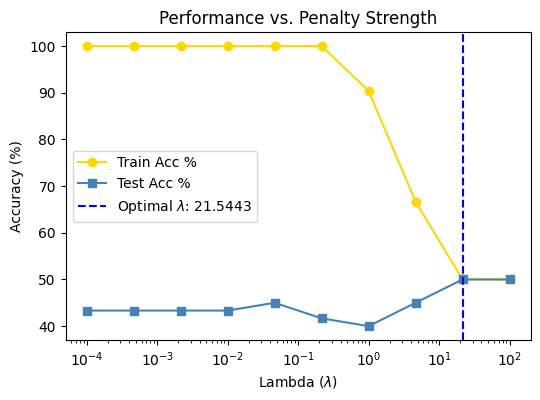

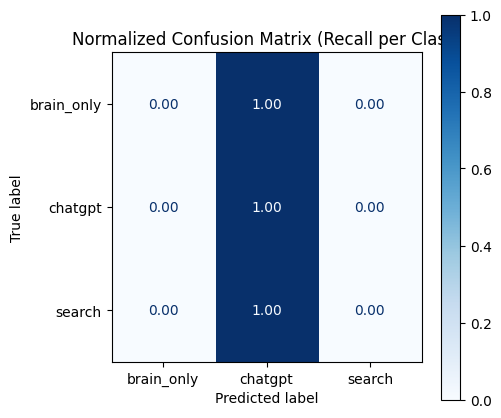

/tmp/ipykernel_5741/3787722071.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")
/tmp/ipykernel_5741/3787722071.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")
/tmp/ipykernel_5741/3787722071.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")


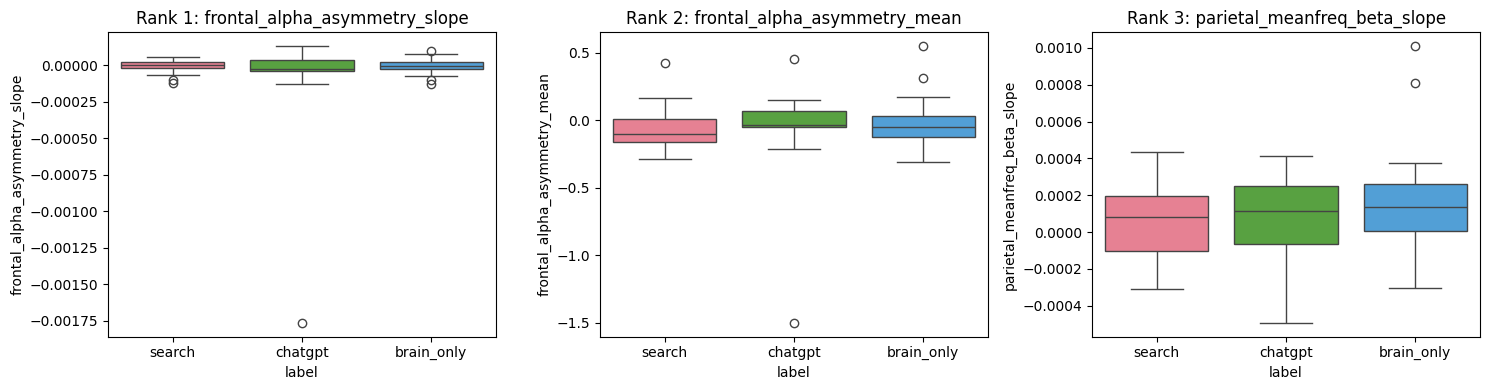

---------------------------------------------
Optimal Lambda:           21.5443
Max Testing Accuracy:     50.00%
Number of classes the model actually predicted: 1
Classes predicted in test set: ['chatgpt']
Top 3 Features:           ['frontal_alpha_asymmetry_slope', 'frontal_alpha_asymmetry_mean', 'parietal_meanfreq_beta_slope']
---------------------------------------------


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Setup Data
target_col = 'label'
group_col = 'subject_id'
X = data.drop(columns=[target_col, group_col])
y_labels = data[target_col]
groups = data[group_col]

le = LabelEncoder()
y = le.fit_transform(y_labels)

# 2. Optimization Loop
lambda_values = np.logspace(-4, 2, 10)
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X, y, groups=groups))

train_acc_mean, test_acc_mean = [], []

for l_val in lambda_values:
    c_val = 1.0 / l_val
    fold_tr, fold_te = [], []
    for tr, te in cv_splits:
        scaler = StandardScaler()
        X_tr, X_te = scaler.fit_transform(X.iloc[tr]), scaler.transform(X.iloc[te])

        clf = LogisticRegression(C=c_val, penalty='l1', solver='saga', multi_class='multinomial',
                                 max_iter=5000, random_state=42, class_weight='balanced')
        clf.fit(X_tr, y[tr])
        fold_tr.append(clf.score(X_tr, y[tr]))
        fold_te.append(clf.score(X_te, y[te]))
    train_acc_mean.append(np.mean(fold_tr))
    test_acc_mean.append(np.mean(fold_te))

# 3. Final Model Evaluation
best_idx = np.argmax(test_acc_mean)
best_lambda = lambda_values[best_idx]
tr_idx, te_idx = cv_splits[-1]

scaler_f = StandardScaler()
X_tr_f, X_te_f = scaler_f.fit_transform(X.iloc[tr_idx]), scaler_f.transform(X.iloc[te_idx])

final_model = LogisticRegression(C=1.0/best_lambda, penalty='l1', solver='saga',
                                 multi_class='multinomial', max_iter=5000, class_weight='balanced')
final_model.fit(X_tr_f, y[tr_idx])
y_pred = final_model.predict(X_te_f)

# --- NEW: Check Prediction Diversity ---
unique_preds = np.unique(y_pred)
predicted_class_names = le.inverse_transform(unique_preds)

# --- VISUALIZATIONS ---

# Plot 1: Accuracy % vs Lambda
plt.figure(figsize=(6, 4))
plt.semilogx(lambda_values, [a*100 for a in train_acc_mean], label='Train Acc %', marker='o', color='gold')
plt.semilogx(lambda_values, [a*100 for a in test_acc_mean], label='Test Acc %', marker='s', color='steelblue')
plt.axvline(best_lambda, color='blue', linestyle='--', label=rf'Optimal $\lambda$: {best_lambda:.4f}')
plt.ylabel('Accuracy (%)')
plt.xlabel(r'Lambda ($\lambda$)')
plt.title('Performance vs. Penalty Strength')
plt.legend()
plt.show()

# Plot 2: Normalized Confusion Matrix (Shows % of each class correctly identified)
fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y[te_idx], y_pred, normalize='true') # Normalization is key here
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Recall per Class)")
plt.show()

# Plot 3: Top 3 Features
importance = np.sum(np.abs(final_model.coef_), axis=0)
top_features = X.columns[np.argsort(importance)[-3:][::-1]]
plt.figure(figsize=(15, 4))
for i, feature in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=y_labels, y=data[feature], palette="husl")
    plt.title(f"Rank {i+1}: {feature}")
plt.tight_layout()
plt.show()

# 4. Final Written Results
print("-" * 45)
print(f"Optimal Lambda:           {best_lambda:.4f}")
print(f"Max Testing Accuracy:     {test_acc_mean[best_idx]*100:.2f}%")
print(f"Number of classes the model actually predicted: {len(unique_preds)}")
print(f"Classes predicted in test set: {list(predicted_class_names)}")
print(f"Top 3 Features:           {top_features.tolist()}")
print("-" * 45)

Running Grid Search over Lambdas...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

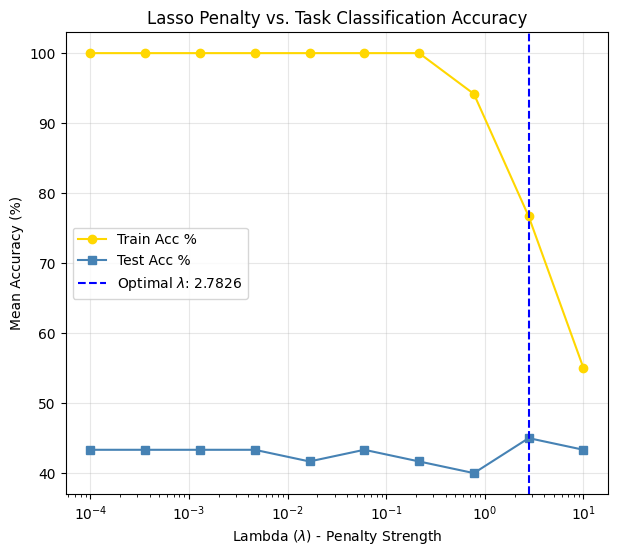

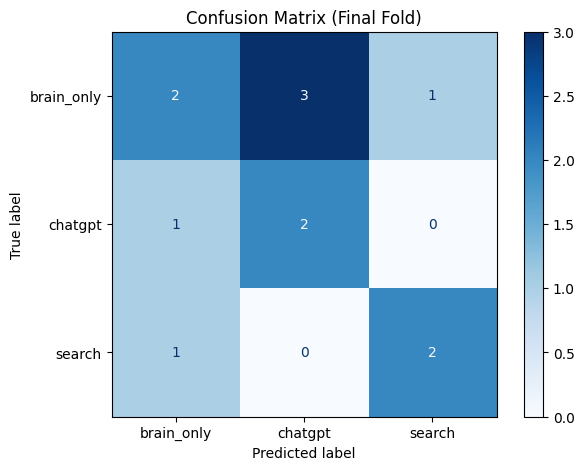

/tmp/ipykernel_5741/977285756.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")
/tmp/ipykernel_5741/977285756.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")
/tmp/ipykernel_5741/977285756.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")


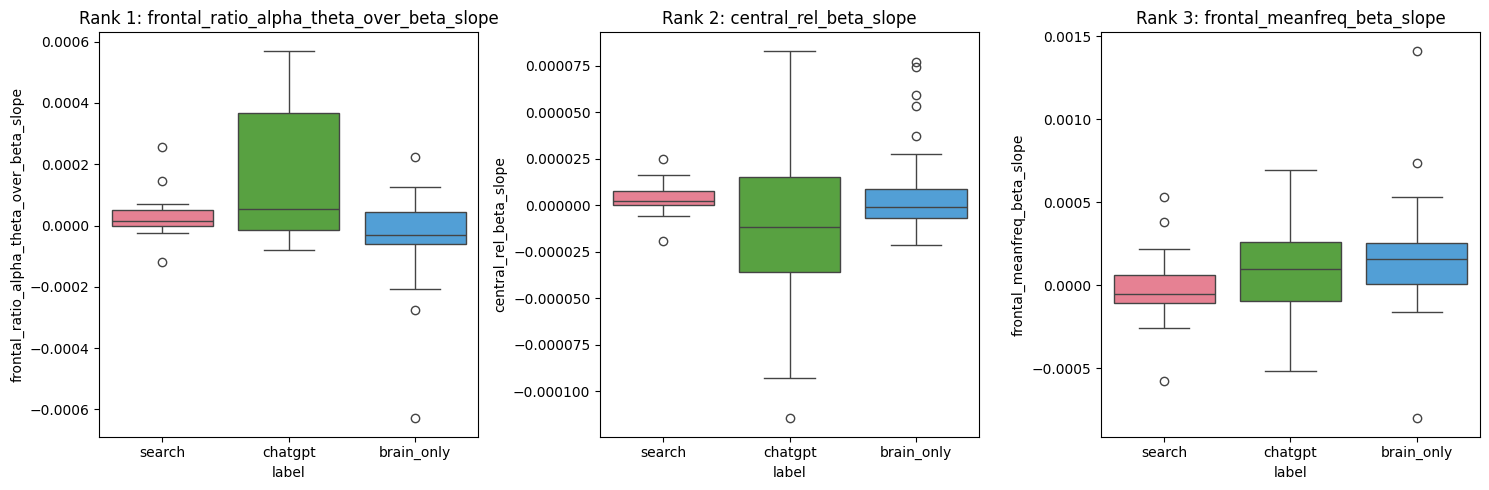

----------------------------------------
Optimal Lambda:         2.7826
Features Kept by Lasso: 24 / 170
Max Training Accuracy:  76.67%
Max Testing Accuracy:   45.00%
Top 3 Features:         ['frontal_ratio_alpha_theta_over_beta_slope', 'central_rel_beta_slope', 'frontal_meanfreq_beta_slope']
----------------------------------------


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Setup Data
target_col = 'label'
group_col = 'subject_id'

# Features (X) exclude both the Label and the Subject_ID
X = data.drop(columns=[target_col, group_col])
y_labels = data[target_col]
groups = data[group_col]

le = LabelEncoder()
y = le.fit_transform(y_labels)

# 2. Optimization Loop
# testing 10 lambdas from 0.0001 up to 10.0
lambda_values = np.logspace(-4, 1, 10)
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X, y, groups=groups))

train_acc_mean = []
test_acc_mean = []

print("Running Grid Search over Lambdas...")

for l_val in lambda_values:
    c_val = 1.0 / l_val
    fold_train_acc = []
    fold_test_acc = []

    for train_idx, test_idx in cv_splits:
        scaler = StandardScaler()
        # Scale ONLY on training subjects to prevent leakage
        X_tr = scaler.fit_transform(X.iloc[train_idx])
        X_te = scaler.transform(X.iloc[test_idx])

        clf = LogisticRegression(
            C=c_val,
            penalty='l1',
            solver='saga',
            multi_class='multinomial',
            max_iter=5000,
            random_state=42,
            class_weight='balanced'
        )
        clf.fit(X_tr, y[train_idx])

        fold_train_acc.append(clf.score(X_tr, y[train_idx]))
        fold_test_acc.append(clf.score(X_te, y[test_idx]))

    train_acc_mean.append(np.mean(fold_train_acc))
    test_acc_mean.append(np.mean(fold_test_acc))

# 3. Final Model at the peak of Testing Accuracy
best_idx = np.argmax(test_acc_mean)
best_lambda = lambda_values[best_idx]
tr_idx, te_idx = cv_splits[-1]

# Scale final training set for coefficient extraction
scaler_final = StandardScaler()
X_tr_final_scaled = scaler_final.fit_transform(X.iloc[tr_idx])
X_te_final_scaled = scaler_final.transform(X.iloc[te_idx])

final_model = LogisticRegression(
    C=1.0/best_lambda,
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    max_iter=5000,
    class_weight='balanced'
)
final_model.fit(X_tr_final_scaled, y[tr_idx])
y_pred = final_model.predict(X_te_final_scaled)

# --- Feature Selection Metrics ---
non_zero_features = np.any(final_model.coef_ != 0, axis=0)
num_features_kept = np.sum(non_zero_features)

# --- Visualizations ---

# Plot 1: Accuracy Curve (Percent)
plt.figure(figsize=(7, 6))
plt.semilogx(lambda_values, [a*100 for a in train_acc_mean], label='Train Acc %', marker='o', color='gold')
plt.semilogx(lambda_values, [a*100 for a in test_acc_mean], label='Test Acc %', marker='s', color='steelblue')
plt.axvline(best_lambda, color='blue', linestyle='--', label=rf'Optimal $\lambda$: {best_lambda:.4f}')
plt.xlabel(r'Lambda ($\lambda$) - Penalty Strength')
plt.ylabel('Mean Accuracy (%)')
plt.title('Lasso Penalty vs. Task Classification Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y[te_idx], y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix (Final Fold)")
plt.show()

# Plot 3: Boxplots for Top 3 Features
importance = np.sum(np.abs(final_model.coef_), axis=0)
top_features = X.columns[np.argsort(importance)[-3:][::-1]]
plt.figure(figsize=(15, 5))
for i, feature in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=y_labels, y=data[feature], palette="husl")
    plt.title(f"Rank {i+1}: {feature}")
plt.tight_layout()
plt.show()

# 4. Final Written Results
print("-" * 40)
print(f"Optimal Lambda:         {best_lambda:.4f}")
print(f"Features Kept by Lasso: {num_features_kept} / {X.shape[1]}")
print(f"Max Training Accuracy:  {train_acc_mean[best_idx]*100:.2f}%")
print(f"Max Testing Accuracy:   {test_acc_mean[best_idx]*100:.2f}%")
print(f"Top 3 Features:         {top_features.tolist()}")
print("-" * 40)

Running Grid Search for Ridge Regression (L2)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

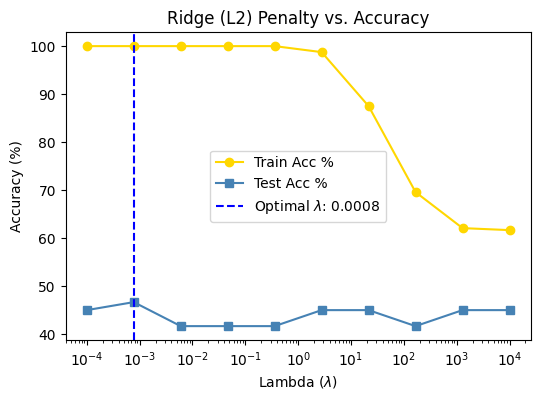

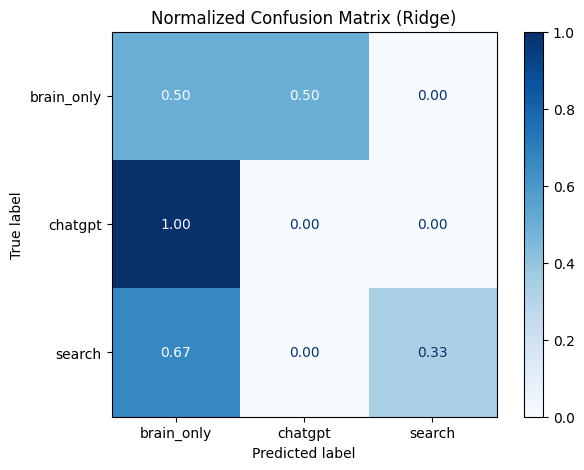

/tmp/ipykernel_5741/3947839293.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")
/tmp/ipykernel_5741/3947839293.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")
/tmp/ipykernel_5741/3947839293.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=data[feature], palette="husl")


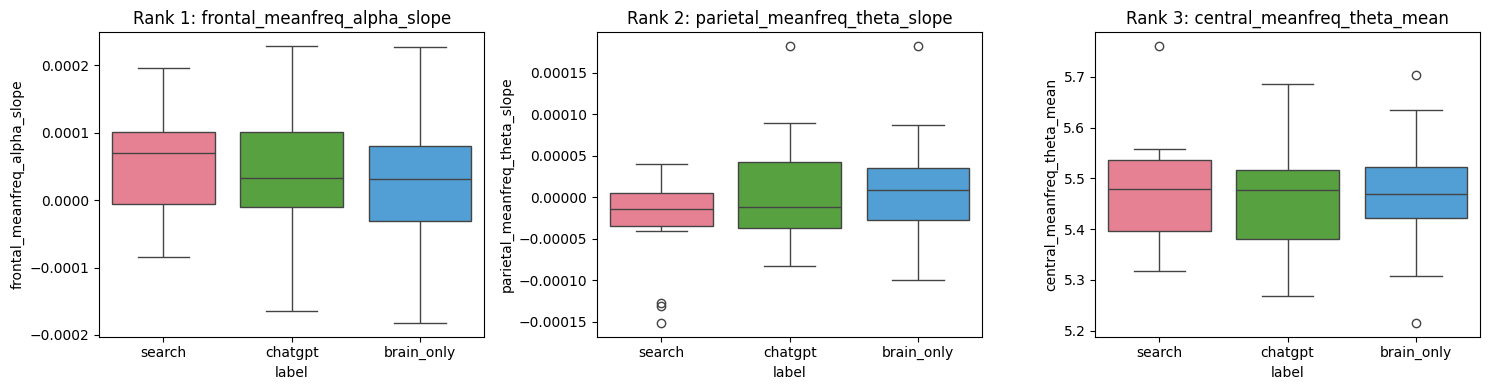

---------------------------------------------
Optimal Ridge Lambda:     0.0008
Features Kept by Ridge:   170 (Ridge keeps all features)
Max Training Accuracy:    100.00%
Max Testing Accuracy:     46.67%
Top 3 Predictive Features: ['frontal_meanfreq_alpha_slope', 'parietal_meanfreq_theta_slope', 'central_meanfreq_theta_mean']
---------------------------------------------


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Setup Data
target_col = 'label'
group_col = 'subject_id'
X = data.drop(columns=[target_col, group_col])
y_labels = data[target_col]
groups = data[group_col]

le = LabelEncoder()
y = le.fit_transform(y_labels)

# 2. Optimization Loop (Ridge / L2)
lambda_values = np.logspace(-4, 4, 10) # Ridge often handles higher lambda ranges better
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X, y, groups=groups))

train_acc_mean = []
test_acc_mean = []

print("Running Grid Search for Ridge Regression (L2)...")

for l_val in lambda_values:
    c_val = 1.0 / l_val
    fold_train, fold_test = [], []
    for tr, te in cv_splits:
        scaler = StandardScaler()
        X_tr, X_te = scaler.fit_transform(X.iloc[tr]), scaler.transform(X.iloc[te])

        # Change penalty to 'l2'
        # 'lbfgs' is the standard solver for Ridge (much faster than saga for L2)
        clf = LogisticRegression(C=c_val, penalty='l2', solver='lbfgs', multi_class='multinomial',
                                 max_iter=5000, random_state=42, class_weight='balanced')
        clf.fit(X_tr, y[tr])
        fold_train.append(clf.score(X_tr, y[tr]))
        fold_test.append(clf.score(X_te, y[te]))
    train_acc_mean.append(np.mean(fold_train))
    test_acc_mean.append(np.mean(fold_test))

# 3. Final Model Evaluation
best_idx = np.argmax(test_acc_mean)
best_lambda = lambda_values[best_idx]
tr_idx, te_idx = cv_splits[-1]

scaler_f = StandardScaler()
X_tr_f, X_te_f = scaler_f.fit_transform(X.iloc[tr_idx]), scaler_f.transform(X.iloc[te_idx])

final_model = LogisticRegression(C=1.0/best_lambda, penalty='l2', solver='lbfgs',
                                 multi_class='multinomial', max_iter=5000, class_weight='balanced')
final_model.fit(X_tr_f, y[tr_idx])
y_pred = final_model.predict(X_te_f)

# --- VISUALIZATIONS ---

# Plot 1: Accuracy % vs Lambda
plt.figure(figsize=(6, 4))
plt.semilogx(lambda_values, [a*100 for a in train_acc_mean], label='Train Acc %', marker='o', color='gold')
plt.semilogx(lambda_values, [a*100 for a in test_acc_mean], label='Test Acc %', marker='s', color='steelblue')
plt.axvline(best_lambda, color='blue', linestyle='--', label=rf'Optimal $\lambda$: {best_lambda:.4f}')
plt.ylabel('Accuracy (%)')
plt.xlabel(r'Lambda ($\lambda$)')
plt.title('Ridge (L2) Penalty vs. Accuracy')
plt.legend()
plt.show()

# Plot 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y[te_idx], y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Ridge)")
plt.show()

# Plot 3: Top 3 Features
importance = np.sum(np.abs(final_model.coef_), axis=0)
top_features = X.columns[np.argsort(importance)[-3:][::-1]]
plt.figure(figsize=(15, 4))
for i, feature in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=y_labels, y=data[feature], palette="husl")
    plt.title(f"Rank {i+1}: {feature}")
plt.tight_layout()
plt.show()

# 4. Final Results
print("-" * 45)
print(f"Optimal Ridge Lambda:     {best_lambda:.4f}")
print(f"Features Kept by Ridge:   {X.shape[1]} (Ridge keeps all features)")
print(f"Max Training Accuracy:    {train_acc_mean[best_idx]*100:.2f}%")
print(f"Max Testing Accuracy:     {test_acc_mean[best_idx]*100:.2f}%")
print(f"Top 3 Predictive Features: {top_features.tolist()}")
print("-" * 45)

Running Ridge Regression with Fixed Lambda = 1000...


<>:71: SyntaxWarning: invalid escape sequence '\l'
<>:71: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5741/1160102793.py:71: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Confusion Matrix (Fixed $\lambda$={fixed_lambda})")
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on,

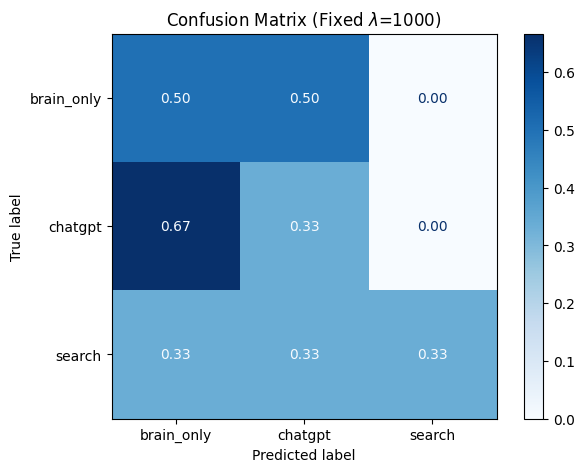

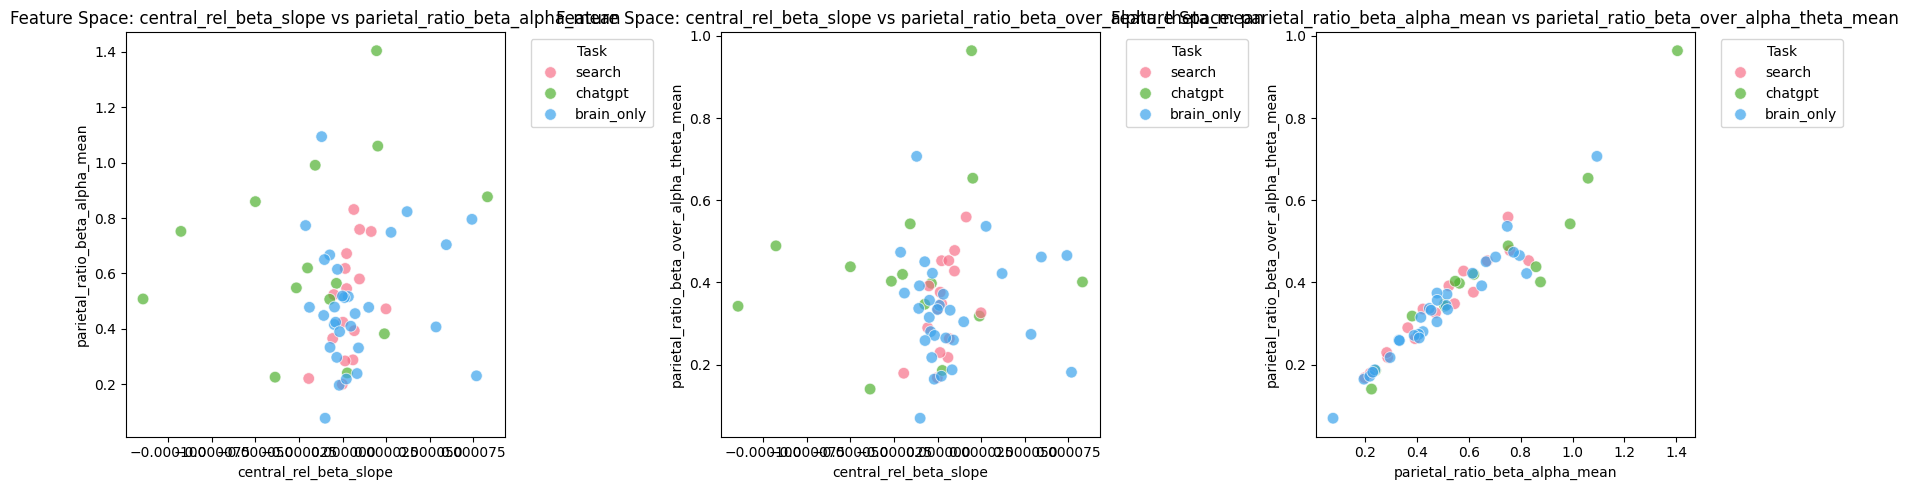

---------------------------------------------
Fixed Ridge Lambda:       1000
Mean Training Accuracy:   64.17%
Mean Testing Accuracy:    45.00%
Top 3 Predictive Features: ['central_rel_beta_slope', 'parietal_ratio_beta_alpha_mean', 'parietal_ratio_beta_over_alpha_theta_mean']
---------------------------------------------


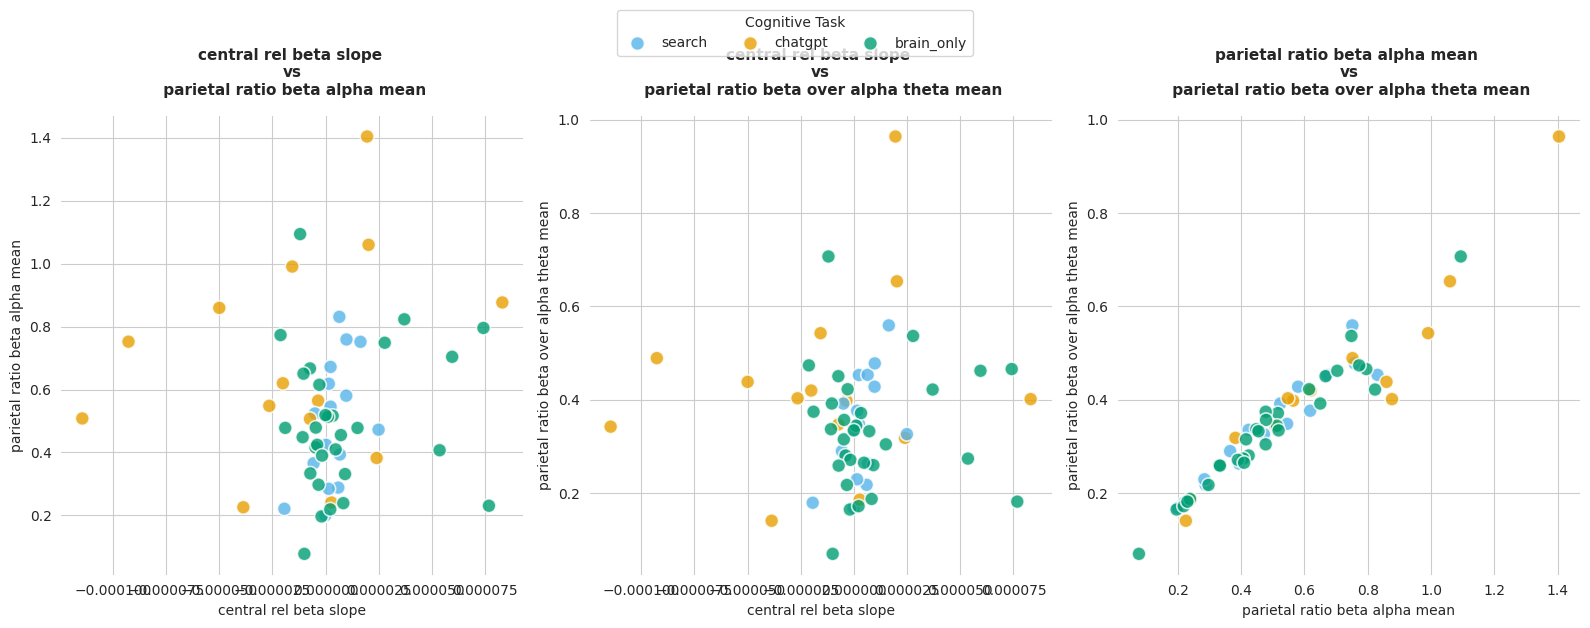

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Setup Data
target_col = 'label'
group_col = 'subject_id'
X = data.drop(columns=[target_col, group_col])
y_labels = data[target_col]
groups = data[group_col]

le = LabelEncoder()
y = le.fit_transform(y_labels)

# 2. Fixed Ridge Model (Lambda = 1000)
fixed_lambda = 1000
fixed_c = 1.0 / fixed_lambda

gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X, y, groups=groups))

fold_train_acc = []
fold_test_acc = []

print(f"Running Ridge Regression with Fixed Lambda = {fixed_lambda}...")

# Run Cross-Validation to get an honest accuracy estimate
for train_idx, test_idx in cv_splits:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X.iloc[train_idx])
    X_te = scaler.transform(X.iloc[test_idx])

    clf = LogisticRegression(
        C=fixed_c,
        penalty='l2',
        solver='lbfgs',
        multi_class='multinomial',
        max_iter=5000,
        random_state=42,
        class_weight='balanced'
    )
    clf.fit(X_tr, y[train_idx])

    fold_train_acc.append(clf.score(X_tr, y[train_idx]))
    fold_test_acc.append(clf.score(X_te, y[test_idx]))

# 3. Final Model Evaluation (on the last fold for visualization)
tr_idx, te_idx = cv_splits[-1]
scaler_f = StandardScaler()
X_tr_f = scaler_f.fit_transform(X.iloc[tr_idx])
X_te_f = scaler_f.transform(X.iloc[te_idx])

final_model = LogisticRegression(C=fixed_c, penalty='l2', solver='lbfgs',
                                 multi_class='multinomial', max_iter=5000, class_weight='balanced')
final_model.fit(X_tr_f, y[tr_idx])
y_pred = final_model.predict(X_te_f)

# --- VISUALIZATIONS ---

# Plot 1: Normalized Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y[te_idx], y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title(f"Confusion Matrix (Fixed $\lambda$={fixed_lambda})")
plt.show()

# Plot 2: 2D Pairwise Scatter Plots of Top 3 Features
importance = np.sum(np.abs(final_model.coef_), axis=0)
top_features = X.columns[np.argsort(importance)[-3:][::-1]]
feature_pairs = list(combinations(top_features, 2))

plt.figure(figsize=(18, 5))
for i, (f_x, f_y) in enumerate(feature_pairs):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(data=data, x=f_x, y=f_y, hue=target_col, palette="husl", alpha=0.7, s=70, edgecolor='w')
    plt.title(f"Feature Space: {f_x} vs {f_y}")
    plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Final Written Results
avg_train = np.mean(fold_train_acc) * 100
avg_test = np.mean(fold_test_acc) * 100

print("-" * 45)
print(f"Fixed Ridge Lambda:       {fixed_lambda}")
print(f"Mean Training Accuracy:   {avg_train:.2f}%")
print(f"Mean Testing Accuracy:    {avg_test:.2f}%")
print(f"Top 3 Predictive Features: {top_features.tolist()}")
print("-" * 45)

# --- IMPROVED VISUALIZATIONS ---

# Set a professional whitegrid style
sns.set_style("whitegrid")

# Define a professional, colorblind-friendly palette
# Steel Blue, Muted Orange, and a soft Sage Green
custom_palette = {"search": "#56B4E9", "chatgpt": "#E69F00", "brain_only": "#009E73"}

importance = np.sum(np.abs(final_model.coef_), axis=0)
top_features = X.columns[np.argsort(importance)[-3:][::-1]]
feature_pairs = list(combinations(top_features, 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, (f_x, f_y) in enumerate(feature_pairs):
    ax = axes[i]

    # Increase 's' for point size and 'edgecolor' for clarity
    sns.scatterplot(
        data=data, x=f_x, y=f_y, hue=target_col,
        palette=custom_palette, alpha=0.8, s=100,
        edgecolor='white', linewidth=1.2, ax=ax
    )

    # Simplify Titles: Remove underscores for a cleaner look
    clean_title = f"{f_x.replace('_', ' ')} \nvs\n {f_y.replace('_', ' ')}"
    ax.set_title(clean_title, fontsize=11, fontweight='bold', pad=15)

    # Clean up axes labels
    ax.set_xlabel(f_x.replace('_', ' '), fontsize=10)
    ax.set_ylabel(f_y.replace('_', ' '), fontsize=10)

    # Remove individual legends to avoid clutter
    ax.get_legend().remove()

# Add one single, clean legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=3, title="Cognitive Task", frameon=True)

plt.tight_layout()
sns.despine(left=True, bottom=True) # Modern, open feel
plt.show()

In [9]:
import pandas as pd

# 1. Define your specific biomarker terms
include_terms = [
    'ratio_theta_beta',
    '_ratio_alpha_theta_over_beta',
    'meanfreq',
    'asymmetry',
    'abs'
]

# 2. Identify all columns that match these terms
# We exclude 'label' and 'subject_id' from the count to see only the biomarkers
selected_biomarkers = [col for col in data.columns if any(term in col for term in include_terms)]
metadata_cols = ['label', 'subject_id']

# 3. Define the new dataframe
fs_data = data[metadata_cols + selected_biomarkers].copy()

# 4. Print the full list
print("-" * 60)
print(f"COMPLETE LIST OF SELECTED FEATURES ({len(selected_biomarkers)} TOTAL)")
print("-" * 60)

# Sort the list alphabetically so it's easier to read by brain region
for i, col in enumerate(sorted(selected_biomarkers), 1):
    print(f"{i:3}. {col}")

print("-" * 60)
print("Dataframe 'fs_data' successfully created with the above features.")

------------------------------------------------------------
COMPLETE LIST OF SELECTED FEATURES (68 TOTAL)
------------------------------------------------------------
  1. central_abs_alpha_mean
  2. central_abs_alpha_slope
  3. central_abs_beta_mean
  4. central_abs_beta_slope
  5. central_abs_delta_mean
  6. central_abs_delta_slope
  7. central_abs_theta_mean
  8. central_abs_theta_slope
  9. central_meanfreq_alpha_mean
 10. central_meanfreq_alpha_slope
 11. central_meanfreq_beta_mean
 12. central_meanfreq_beta_slope
 13. central_meanfreq_delta_mean
 14. central_meanfreq_delta_slope
 15. central_meanfreq_theta_mean
 16. central_meanfreq_theta_slope
 17. central_meanfreq_total_mean
 18. central_meanfreq_total_slope
 19. central_ratio_alpha_theta_over_beta_mean
 20. central_ratio_alpha_theta_over_beta_slope
 21. central_ratio_theta_beta_mean
 22. central_ratio_theta_beta_slope
 23. frontal_abs_alpha_mean
 24. frontal_abs_alpha_slope
 25. frontal_abs_beta_mean
 26. frontal_abs_beta_slo

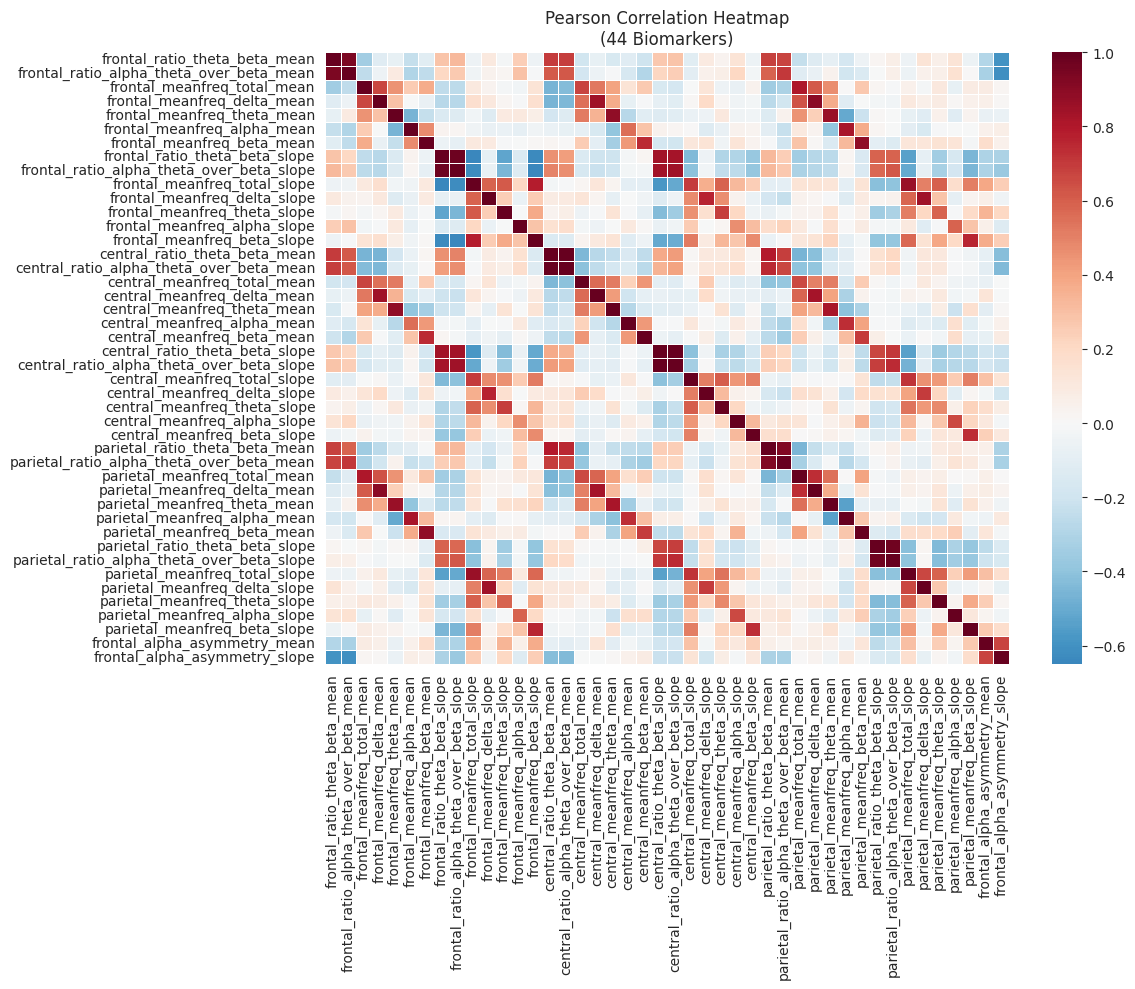

------------------------------------------------------------
TOP 20 CORRELATED BIOMARKER PAIRS (BY MAGNITUDE)
------------------------------------------------------------
                                 Feature_1                                 Feature_2  Pearson_r  Magnitude
  central_ratio_alpha_theta_over_beta_mean             central_ratio_theta_beta_mean   0.992584   0.992584
 central_ratio_alpha_theta_over_beta_slope            central_ratio_theta_beta_slope   0.988166   0.988166
 frontal_ratio_alpha_theta_over_beta_slope            frontal_ratio_theta_beta_slope   0.975915   0.975915
parietal_ratio_alpha_theta_over_beta_slope           parietal_ratio_theta_beta_slope   0.972072   0.972072
  frontal_ratio_alpha_theta_over_beta_mean             frontal_ratio_theta_beta_mean   0.936009   0.936009
 parietal_ratio_alpha_theta_over_beta_mean            parietal_ratio_theta_beta_mean   0.924641   0.924641
              parietal_meanfreq_delta_mean               frontal_meanfreq_delta_

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Re-define the Feature Selection Dataframe
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry']
selected_cols = [col for col in data.columns if any(term in col for term in include_terms)]
fs_data = data[selected_cols].copy()

# 2. Calculate Pearson Correlation Matrix
corr_matrix = fs_data.corr(method='pearson')

# 3. Extract and Rank the Correlation Pairs
# We use the upper triangle to avoid duplicate pairs (A-B and B-A) and self-correlations (A-A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_list = upper_tri.unstack().dropna()

# Create a clean DataFrame for the results
corr_df = pd.DataFrame(corr_list).reset_index()
corr_df.columns = ['Feature_1', 'Feature_2', 'Pearson_r']
corr_df['Magnitude'] = corr_df['Pearson_r'].abs()

# Sort by Magnitude (High to Low)
corr_df = corr_df.sort_values(by='Magnitude', ascending=False)

# 4. Visualization: Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, linewidths=0.5)
plt.title(f"Pearson Correlation Heatmap\n({len(selected_cols)} Biomarkers)")
plt.tight_layout()
plt.show()

# 5. Output the Ranked List
print("-" * 60)
print(f"TOP 20 CORRELATED BIOMARKER PAIRS (BY MAGNITUDE)")
print("-" * 60)
print(corr_df.head(30).to_string(index=False))
print("-" * 60)

# Export the full list to CSV for your records
corr_df.to_csv('biomarker_pearson_correlations.csv', index=False)

In [11]:
import pandas as pd
import numpy as np

# 1. Define the terms
target_ratio = 'ratio_theta_beta'
complex_ratio = 'alpha_theta_over_beta'
other_biomarkers = ['meanfreq', 'asymmetry']

# 2. Get all potential features
all_features = [col for col in data.columns if any(term in col for term in [target_ratio, complex_ratio] + other_biomarkers)]

# 3. Smart Filtering for the Complex Ratio
# We calculate the correlation between every complex ratio and every simple ratio
final_selection = []
simple_ratio_cols = [c for c in data.columns if target_ratio in c]
complex_ratio_cols = [c for c in data.columns if complex_ratio in c]
others = [c for c in data.columns if any(term in c for term in other_biomarkers)]

print("Filtering for low-correlation complex ratios...")

for comp in complex_ratio_cols:
    is_redundant = False
    for simp in simple_ratio_cols:
        # Check Pearson correlation
        corr = data[comp].corr(data[simp])
        if abs(corr) > 0.90: # Threshold for "too similar"
            is_redundant = True
            break
    if not is_redundant:
        final_selection.append(comp)

# Add back the essential biomarkers
final_selection.extend(simple_ratio_cols)
final_selection.extend(others)

# 4. Define fs_data
fs_data = data[['label', 'subject_id'] + final_selection].copy()

# 5. Report
print("-" * 60)
print(f"Total Features Kept: {len(final_selection)}")
print(f"Unique Complex Ratios Saved: {len([c for c in final_selection if complex_ratio in c])}")
print("-" * 60)
for i, col in enumerate(sorted(final_selection), 1):
    print(f"{i:3}. {col}")

Filtering for low-correlation complex ratios...
------------------------------------------------------------
Total Features Kept: 38
Unique Complex Ratios Saved: 0
------------------------------------------------------------
  1. central_meanfreq_alpha_mean
  2. central_meanfreq_alpha_slope
  3. central_meanfreq_beta_mean
  4. central_meanfreq_beta_slope
  5. central_meanfreq_delta_mean
  6. central_meanfreq_delta_slope
  7. central_meanfreq_theta_mean
  8. central_meanfreq_theta_slope
  9. central_meanfreq_total_mean
 10. central_meanfreq_total_slope
 11. central_ratio_theta_beta_mean
 12. central_ratio_theta_beta_slope
 13. frontal_alpha_asymmetry_mean
 14. frontal_alpha_asymmetry_slope
 15. frontal_meanfreq_alpha_mean
 16. frontal_meanfreq_alpha_slope
 17. frontal_meanfreq_beta_mean
 18. frontal_meanfreq_beta_slope
 19. frontal_meanfreq_delta_mean
 20. frontal_meanfreq_delta_slope
 21. frontal_meanfreq_theta_mean
 22. frontal_meanfreq_theta_slope
 23. frontal_meanfreq_total_mean
 24

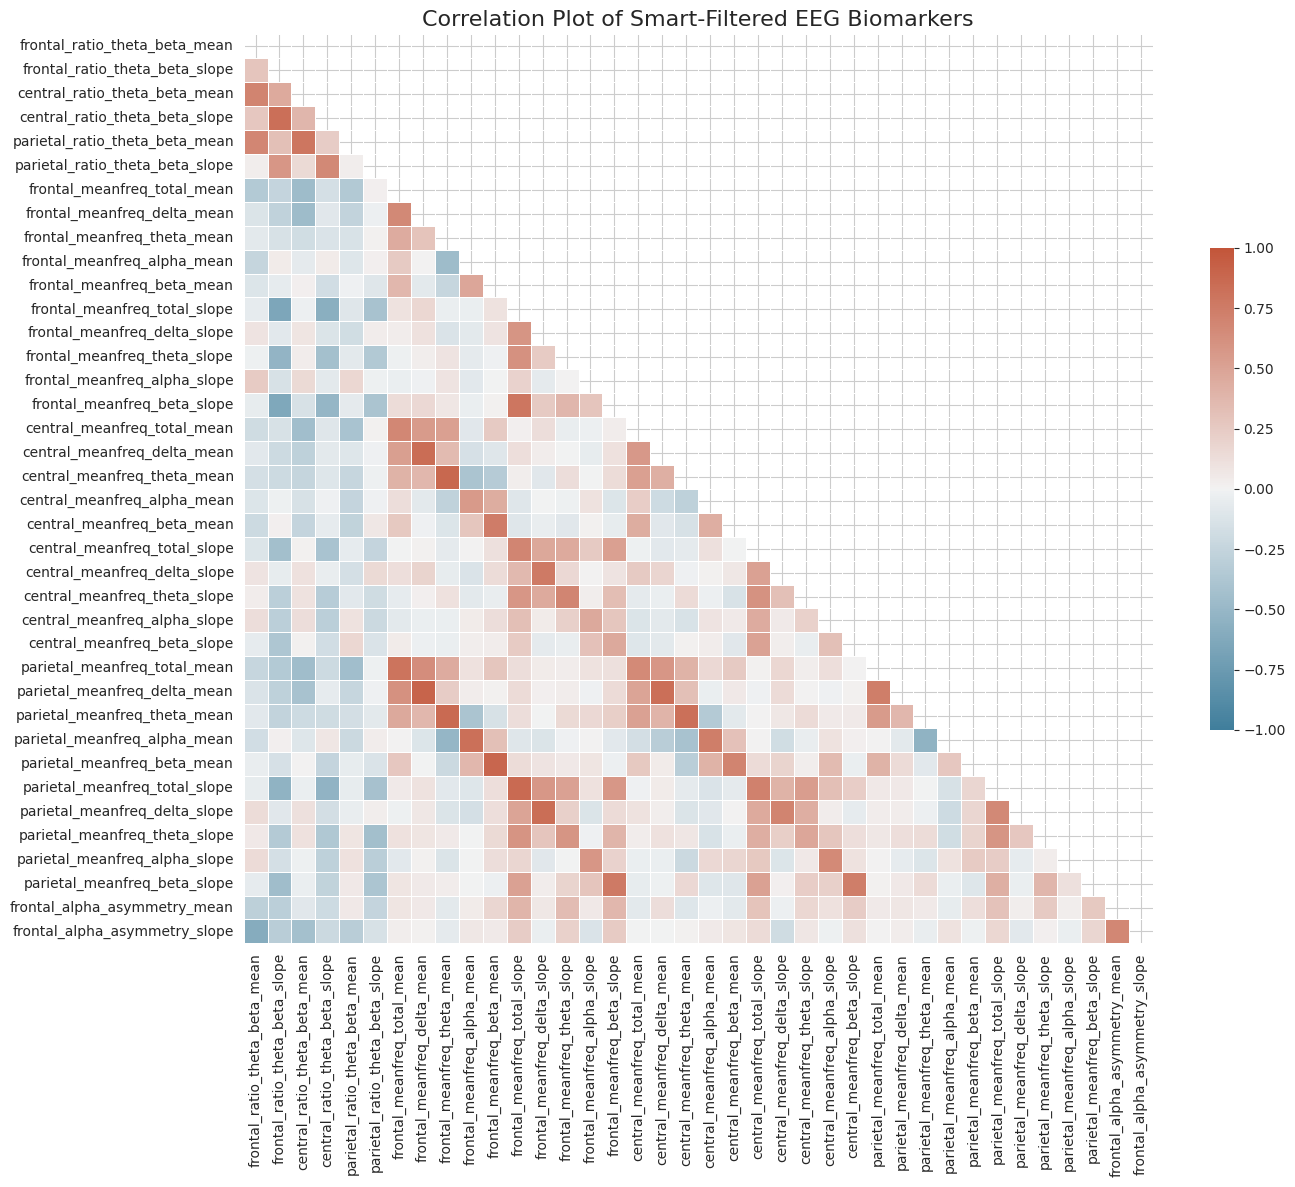

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the Correlation Matrix for the new fs_data
corr = fs_data.drop(columns=['label', 'subject_id']).corr()

# 2. Create a mask for the upper triangle
# (This makes the plot much cleaner by only showing one side of the diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# 4. Generate a custom diverging colormap (Red for positive, Blue for negative)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 5. Draw the heatmap
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=False)

plt.title('Correlation Plot of Smart-Filtered EEG Biomarkers', fontsize=16)
plt.tight_layout()
plt.show()

Training Random Forest on 38 filtered biomarkers...


/tmp/ipykernel_5741/1905997507.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=fs_data[feature], palette="husl", showfliers=False)
/tmp/ipykernel_5741/1905997507.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=fs_data[feature], palette="husl", showfliers=False)
/tmp/ipykernel_5741/1905997507.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_labels, y=fs_data[feature], palette="husl", showfliers=False)


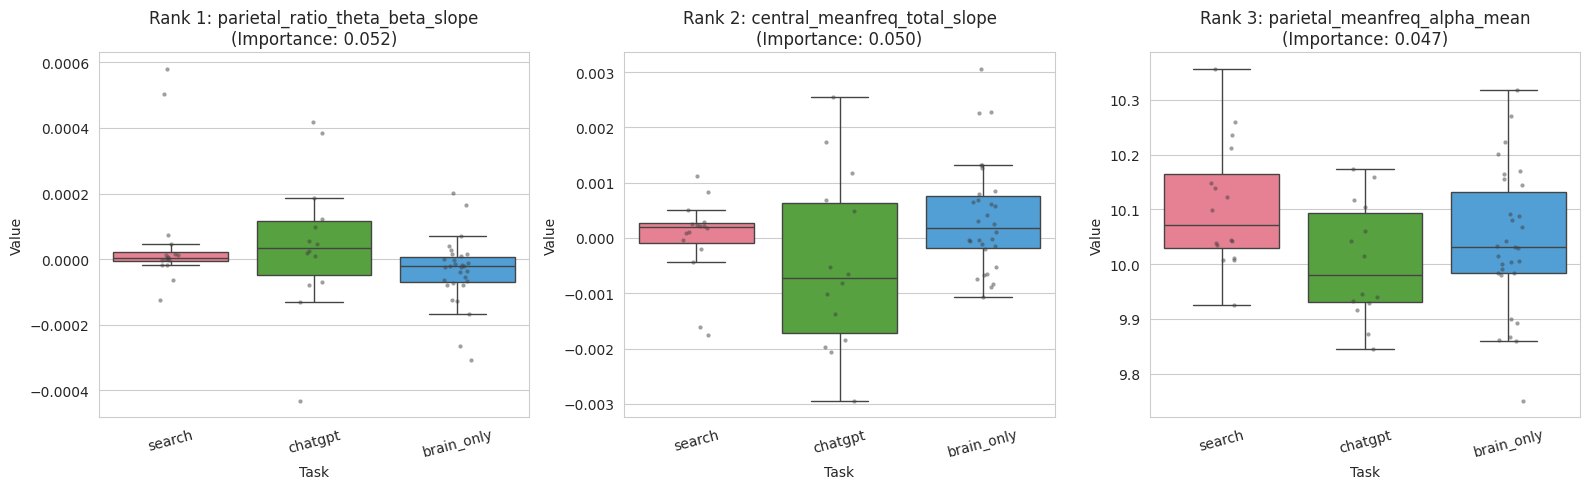

---------------------------------------------
Mean Training Accuracy: 89.17%
Mean Testing Accuracy:  53.33%
Top 3 Biomarkers:       ['parietal_ratio_theta_beta_slope', 'central_meanfreq_total_slope', 'parietal_meanfreq_alpha_mean']
---------------------------------------------


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder

# 1. Setup Data using fs_data (The 38-feature biomarker set)
X = fs_data.drop(columns=['label', 'subject_id'])
y_labels = fs_data['label']
groups = fs_data['subject_id']

le = LabelEncoder()
y = le.fit_transform(y_labels)

# 2. Random Forest with Group Cross-Validation
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X, y, groups=groups))

train_acc, test_acc = [], []
all_importances = []

print(f"Training Random Forest on {X.shape[1]} filtered biomarkers...")

for tr_idx, te_idx in cv_splits:
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # We use 'balanced' weights to handle the uneven sample sizes per task
    rf = RandomForestClassifier(n_estimators=500,
                                max_depth=2,
                                min_samples_leaf=5,
                                class_weight='balanced',
                                random_state=42,
                                n_jobs=-1)
    rf.fit(X_tr, y_tr)

    train_acc.append(rf.score(X_tr, y_tr))
    test_acc.append(rf.score(X_te, y[te_idx]))
    all_importances.append(rf.feature_importances_)

# 3. Identify Top 3 Features based on Mean Importance across all folds
mean_importance = np.mean(all_importances, axis=0)
top_3_idx = np.argsort(mean_importance)[-3:][::-1]
top_3_features = X.columns[top_3_idx]

# --- VISUALIZATIONS ---

# Plot 1: Boxplots for the Top 3 Features
plt.figure(figsize=(16, 5))
for i, feature in enumerate(top_3_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=y_labels, y=fs_data[feature], palette="husl", showfliers=False)
    # Add a swarmplot on top to see the individual subject distributions
    sns.stripplot(x=y_labels, y=fs_data[feature], color=".25", size=3, jitter=True, alpha=0.5)

    plt.title(f"Rank {i+1}: {feature}\n(Importance: {mean_importance[top_3_idx[i]]:.3f})")
    plt.xlabel("Task")
    plt.ylabel("Value")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# 4. Final Written Results
print("-" * 45)
print(f"Mean Training Accuracy: {np.mean(train_acc)*100:.2f}%")
print(f"Mean Testing Accuracy:  {np.mean(test_acc)*100:.2f}%")
print(f"Top 3 Biomarkers:       {top_3_features.tolist()}")
print("-" * 45)

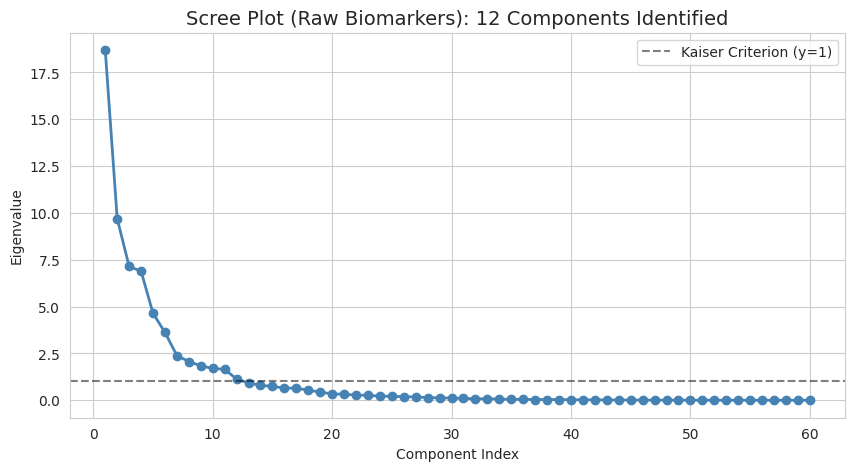

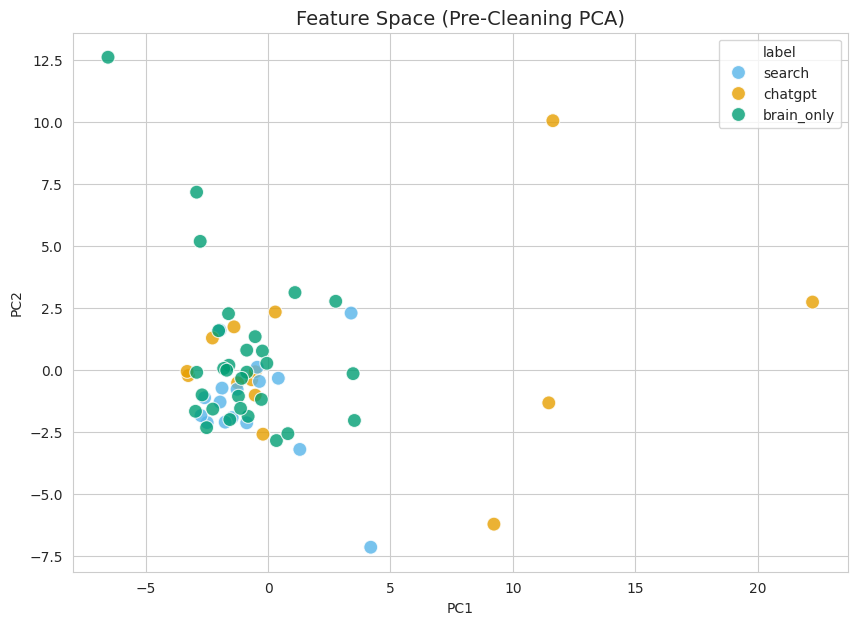

------------------------------------------------------------
TOP LOADINGS (PRE-CLEANING)
------------------------------------------------------------

PC1 Strongest Influences:
central_abs_theta_mean                       0.196408
central_abs_delta_mean                       0.195835
central_abs_alpha_mean                       0.192612
central_ratio_theta_beta_mean                0.192577
frontal_ratio_alpha_theta_over_beta_slope    0.191220
Name: PC1, dtype: float64

PC2 Strongest Influences:
frontal_meanfreq_total_slope                0.190654
frontal_abs_alpha_mean                      0.190437
frontal_abs_theta_mean                      0.185861
frontal_ratio_alpha_theta_over_beta_mean    0.184810
parietal_abs_alpha_mean                     0.184562
Name: PC2, dtype: float64

PC3 Strongest Influences:
frontal_meanfreq_delta_slope    0.238024
parietal_abs_alpha_slope        0.230929
frontal_abs_delta_mean          0.228159
central_abs_alpha_slope         0.220551
parietal_abs_theta

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold

# 1. Define broad biomarker terms (Pre-Cleaning)
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']
selected_biomarkers = [col for col in data.columns if any(term in col for term in include_terms)]
fs_data_raw = data[['label', 'subject_id'] + selected_biomarkers].copy()

# 2. PCA Pipeline
X = fs_data_raw.drop(columns=['label', 'subject_id'])
y_labels = fs_data_raw['label']
groups = fs_data_raw['subject_id']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)
eigenvalues = pca_full.explained_variance_

# Kaiser Criterion
n_comp = np.sum(eigenvalues > 1)
pca_final = PCA(n_components=n_comp)
X_pca = pca_final.fit_transform(X_scaled)

# 3. Random Forest on PCs
le = LabelEncoder()
y = le.fit_transform(y_labels)
gkf = GroupKFold(n_splits=5)
tr_acc, te_acc = [], []

for tr_idx, te_idx in gkf.split(X_pca, y, groups=groups):
    rf = RandomForestClassifier(n_estimators=500, max_depth=2, min_samples_leaf=5,
                                class_weight='balanced', random_state=42)
    rf.fit(X_pca[tr_idx], y[tr_idx])
    tr_acc.append(rf.score(X_pca[tr_idx], y[tr_idx]))
    te_acc.append(rf.score(X_pca[te_idx], y[te_idx]))

# --- PROFESSIONAL VISUALIZATIONS ---
sns.set_style("whitegrid")
custom_palette = {"search": "#56B4E9", "chatgpt": "#E69F00", "brain_only": "#009E73"}

# Plot 1: Scree Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Kaiser Criterion (y=1)')
plt.title(f'Scree Plot (Raw Biomarkers): {n_comp} Components Identified', fontsize=14)
plt.ylabel('Eigenvalue')
plt.xlabel('Component Index')
plt.legend()
plt.show()

# Plot 2: 2D PCA Space
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['label'] = y_labels.values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', palette=custom_palette, s=100, edgecolor='white', alpha=0.8)
plt.title('Feature Space (Pre-Cleaning PCA)', fontsize=14)
plt.show()

# --- OUTPUTS ---
print("-" * 60)
print("TOP LOADINGS (PRE-CLEANING)")
print("-" * 60)
loadings = pd.DataFrame(pca_final.components_[:3].T, columns=['PC1', 'PC2', 'PC3'], index=X.columns)
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc} Strongest Influences:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))

print("\n" + "="*45)
print(f"Mean Training Accuracy: {np.mean(tr_acc)*100:.2f}%")
print(f"Mean Testing Accuracy:  {np.mean(te_acc)*100:.2f}%")
print("="*45)

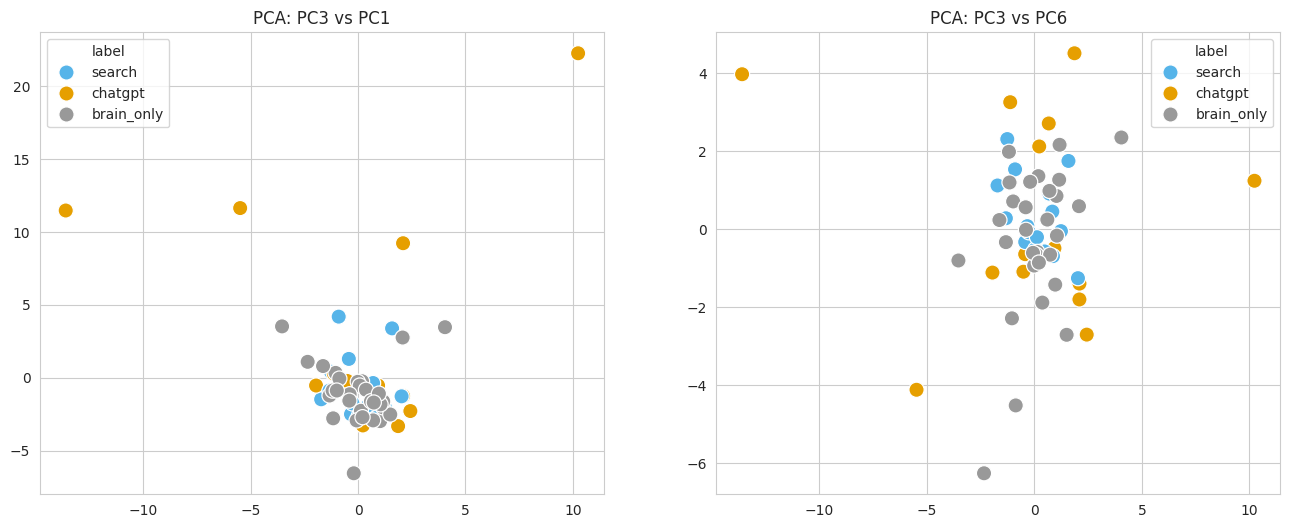

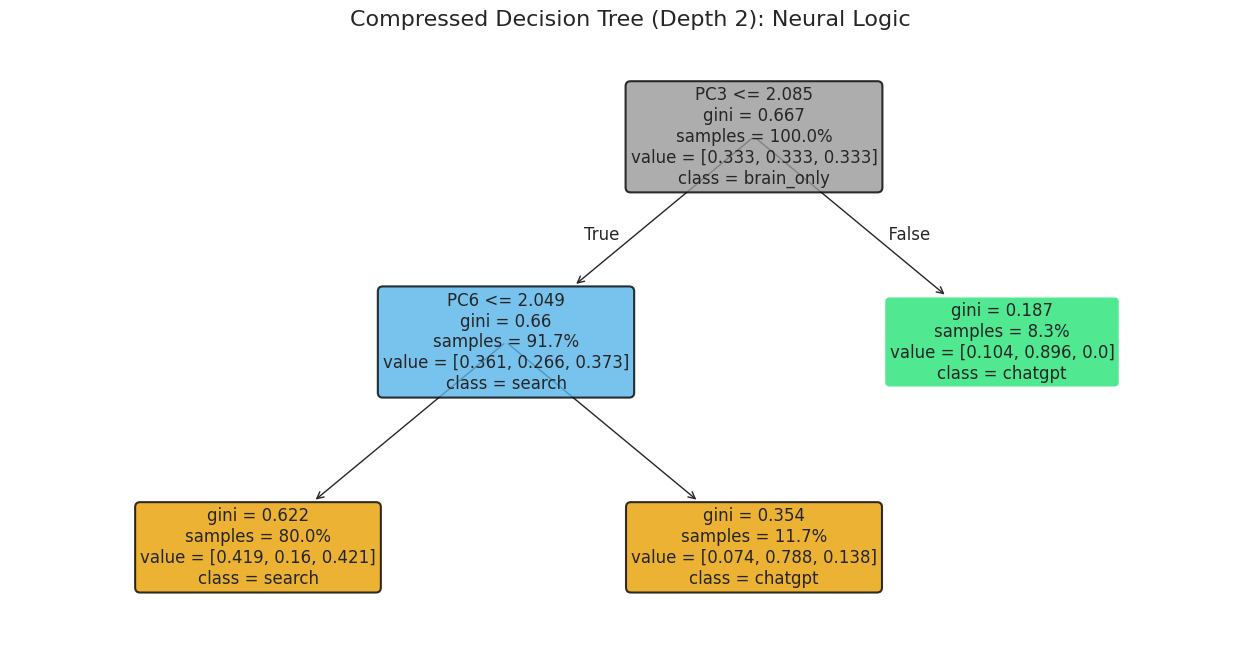

-----------------------------------------------------------------
TOP 5 BIOMARKERS COMPOSING EACH PRINCIPAL COMPONENT
-----------------------------------------------------------------

PC1 COMPOSITION:
    [+] central_abs_theta_mean                   (Weight: 0.196)
    [+] central_abs_delta_mean                   (Weight: 0.196)
    [+] central_abs_alpha_mean                   (Weight: 0.193)
    [+] central_ratio_theta_beta_mean            (Weight: 0.193)
    [+] frontal_ratio_alpha_theta_over_beta_slope (Weight: 0.191)

PC2 COMPOSITION:
    [+] frontal_meanfreq_total_slope             (Weight: 0.191)
    [+] frontal_abs_alpha_mean                   (Weight: 0.190)
    [+] frontal_abs_theta_mean                   (Weight: 0.186)
    [+] frontal_ratio_alpha_theta_over_beta_mean (Weight: 0.185)
    [+] parietal_abs_alpha_mean                  (Weight: 0.185)

PC3 COMPOSITION:
    [+] frontal_meanfreq_delta_slope             (Weight: 0.238)
    [+] parietal_abs_alpha_slope              

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Prepare PCA Data (Ensuring at least 6 components)
# include_terms: ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']
selected_biomarkers = [col for col in data.columns if any(term in col for term in include_terms)]
X_raw = data[selected_biomarkers]
y_labels = data['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Extract at least 6 components for the requested PC3 vs PC6 plot
pca = PCA(n_components=max(6, np.sum(PCA().fit(X_scaled).explained_variance_ > 1)))
X_pca = pca.fit_transform(X_scaled)
pc_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]

# 2. Decision Tree logic (Depth 2)
le = LabelEncoder()
y = le.fit_transform(y_labels)
dt_pruned = DecisionTreeClassifier(max_depth=2, min_samples_leaf=5, class_weight='balanced', random_state=42)
dt_pruned.fit(X_pca, y)

# --- VISUALIZATIONS ---

# Plot A: Requested PCA Cross-Sections
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Using your professional palette: Gold, Steel Blue, Grey
custom_palette = {"brain_only": "#999999", "chatgpt": "#E69F00", "search": "#56B4E9"}

sns.scatterplot(x=X_pca[:, 2], y=X_pca[:, 0], hue=y_labels, palette=custom_palette, s=120, edgecolor='w', ax=axes[0])
axes[0].set_title("PCA: PC3 vs PC1")

sns.scatterplot(x=X_pca[:, 2], y=X_pca[:, 5], hue=y_labels, palette=custom_palette, s=120, edgecolor='w', ax=axes[1])
axes[1].set_title("PCA: PC3 vs PC6")
plt.show()

# Plot B: The Fixed Decision Tree (Gold, SteelBlue, Grey)
fig, ax = plt.subplots(figsize=(16, 8))
node_colors = ["#999999", "#E69F00", "#56B4E9"] # Grey, Gold, SteelBlue

# We use the list of artists returned by plot_tree
# Important: filled=True must be set for bbox to exist
artists = plot_tree(dt_pruned, feature_names=pc_names, class_names=le.classes_,
                    filled=True, rounded=True, fontsize=12, proportion=True, ax=ax)

# FIX: Iterate through nodes using the tree structure length, not the artist list length
# The artists list contains both nodes (Text objects) and edges (Lines).
# We only want to color the Text objects that represent nodes.
node_idx = 0
for artist in artists:
    # Only Text objects with a bbox are nodes we want to color
    if isinstance(artist, plt.Text) and artist.get_text() != "":
        if node_idx < dt_pruned.tree_.node_count:
            winning_class = np.argmax(dt_pruned.tree_.value[node_idx])
            bbox = artist.get_bbox_patch()
            if bbox is not None:
                bbox.set_facecolor(node_colors[winning_class])
                bbox.set_alpha(0.8)
                bbox.set_edgecolor("black")
                bbox.set_linewidth(1.5)
            node_idx += 1

plt.title("Compressed Decision Tree (Depth 2): Neural Logic", fontsize=16)
plt.show()

# --- 3. THE TOP PREDICTORS (LOADINGS) ---
print("-" * 65)
print("TOP 5 BIOMARKERS COMPOSING EACH PRINCIPAL COMPONENT")
print("-" * 65)

loadings = pd.DataFrame(pca.components_.T, columns=pc_names, index=selected_biomarkers)

for pc in pc_names[:6]: # Analyze the first 6 components
    print(f"\n{pc} COMPOSITION:")
    # We sort by absolute magnitude to see what 'drives' the component
    top_5 = loadings[pc].abs().sort_values(ascending=False).head(5)
    for feat, val in top_5.items():
        weight = loadings.loc[feat, pc]
        direction = "[+]" if weight > 0 else "[-]"
        print(f"    {direction} {feat:40} (Weight: {weight:.3f})")

print("-" * 65)

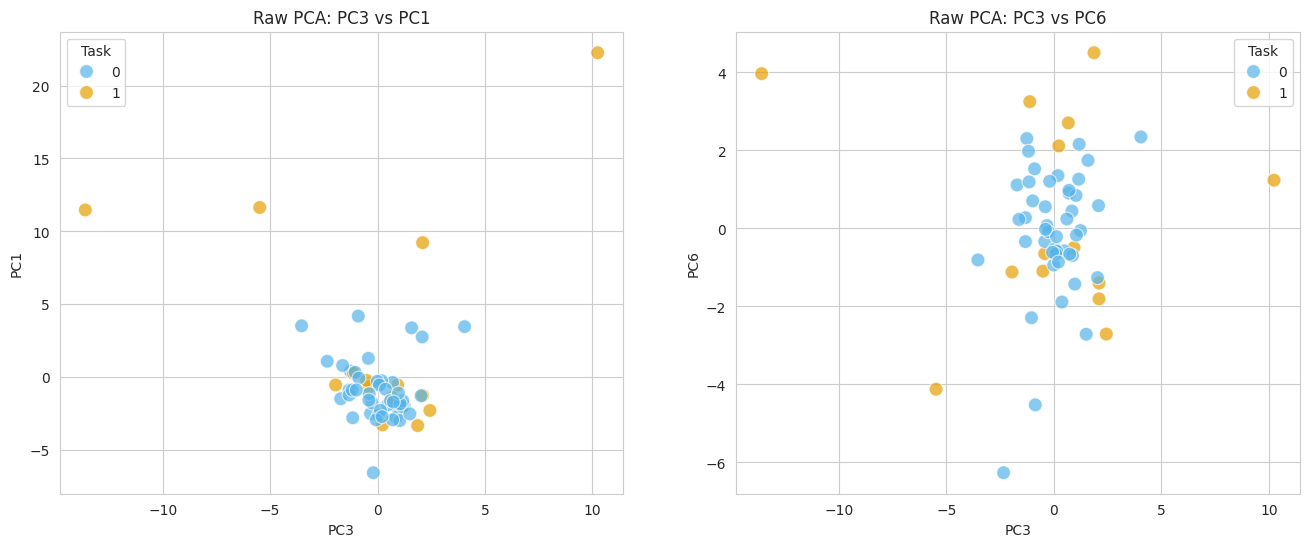

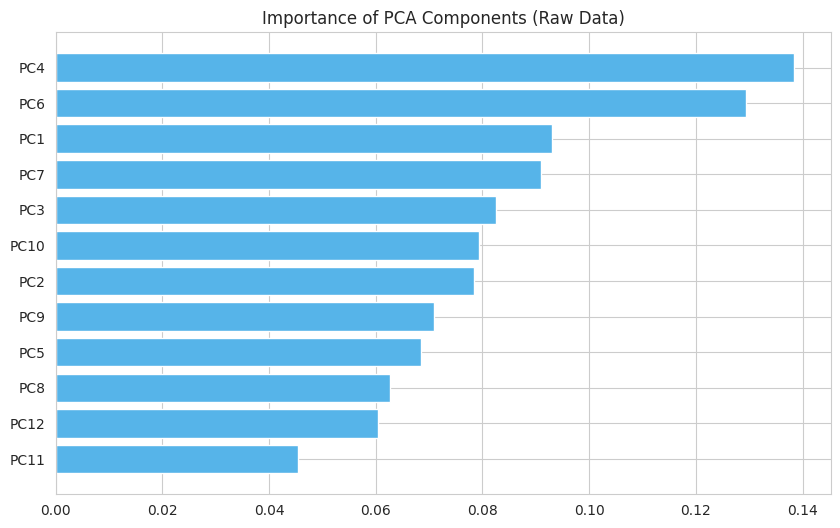

---------------------------------------------
RESULTS: RAW DATA (NO SUBJECT NORM)
---------------------------------------------
Mean Training Accuracy: 97.08%
Mean Testing Accuracy:  70.00%
Mean ROC-AUC:           0.50
---------------------------------------------


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Feature Selection & Binary Labeling
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']
selected_biomarkers = [col for col in data.columns if any(term in col for term in include_terms)]

df_raw_bin = data.copy()
df_raw_bin['binary_label'] = df_raw_bin['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)

X_raw = df_raw_bin[selected_biomarkers]
y = df_raw_bin['binary_label']
groups = df_raw_bin['subject_id']

# 2. Standard PCA (No Group-Wise Normalization)
# We still use StandardScaler to ensure features are on the same scale for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca_full = PCA().fit(X_scaled)
n_comp = max(6, np.sum(pca_full.explained_variance_ > 1))
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_scaled)

pc_names = [f'PC{i+1}' for i in range(n_comp)]

# 3. Random Forest with Group Cross-Validation
gkf = GroupKFold(n_splits=5)
train_accs, test_accs, auc_scores = [], [], []
all_importances = []

for tr_idx, te_idx in gkf.split(X_pca, y, groups=groups):
    rf = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=5,
                                class_weight='balanced', random_state=42)
    rf.fit(X_pca[tr_idx], y[tr_idx])

    train_accs.append(rf.score(X_pca[tr_idx], y[tr_idx]))
    test_accs.append(rf.score(X_pca[te_idx], y[te_idx]))
    auc_scores.append(roc_auc_score(y[te_idx], rf.predict_proba(X_pca[te_idx])[:, 1]))
    all_importances.append(rf.feature_importances_)

# --- VISUALIZATIONS ---
sns.set_style("whitegrid")
custom_palette = {1: "#E69F00", 0: "#56B4E9"} # Gold vs Steel Blue

# Plot 1: PC3 vs PC1 and PC3 vs PC6 (Raw Data)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
pca_df = pd.DataFrame(X_pca, columns=pc_names)
pca_df['Task'] = y

sns.scatterplot(data=pca_df, x='PC3', y='PC1', hue='Task', palette=custom_palette, s=100, edgecolor='w', alpha=0.7, ax=ax1)
ax1.set_title("Raw PCA: PC3 vs PC1")

sns.scatterplot(data=pca_df, x='PC3', y='PC6', hue='Task', palette=custom_palette, s=100, edgecolor='w', alpha=0.7, ax=ax2)
ax2.set_title("Raw PCA: PC3 vs PC6")
plt.show()

# Plot 2: Component Importance
mean_imp = np.mean(all_importances, axis=0)
indices = np.argsort(mean_imp)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), mean_imp[indices], color='#56B4E9')
plt.yticks(range(len(indices)), [pc_names[i] for i in indices])
plt.title('Importance of PCA Components (Raw Data)')
plt.show()

# --- FINAL SUMMARY ---
print("-" * 45)
print("RESULTS: RAW DATA (NO SUBJECT NORM)")
print("-" * 45)
print(f"Mean Training Accuracy: {np.mean(train_accs)*100:.2f}%")
print(f"Mean Testing Accuracy:  {np.mean(test_accs)*100:.2f}%")
print(f"Mean ROC-AUC:           {np.mean(auc_scores):.2f}")
print("-" * 45)

Training Binary PCA-Random Forest on 14 components...


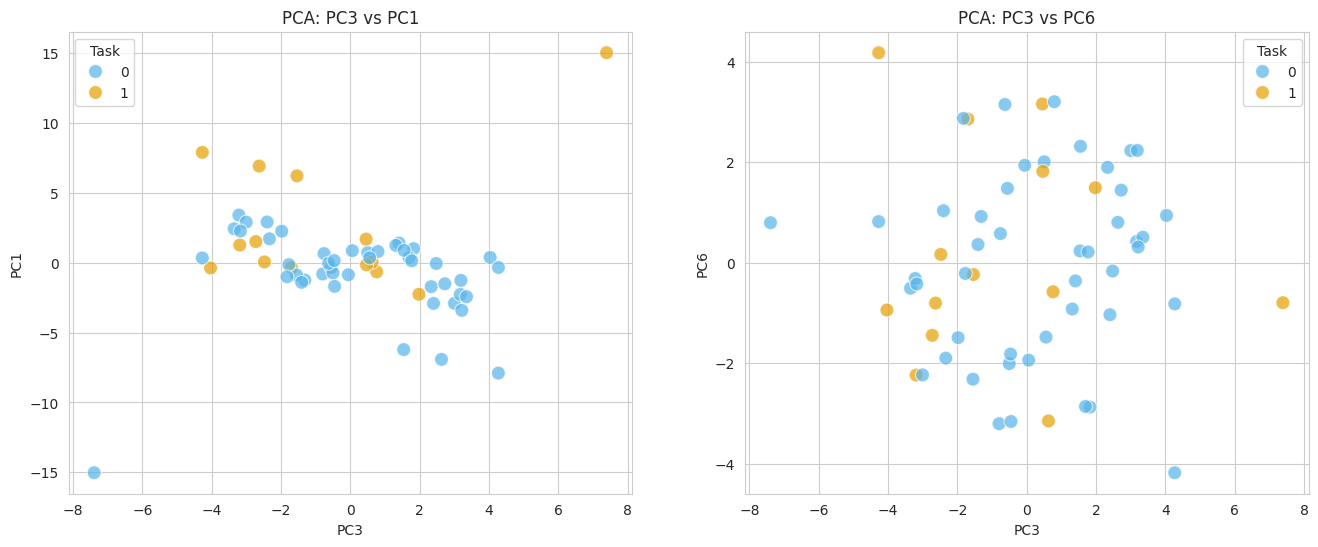

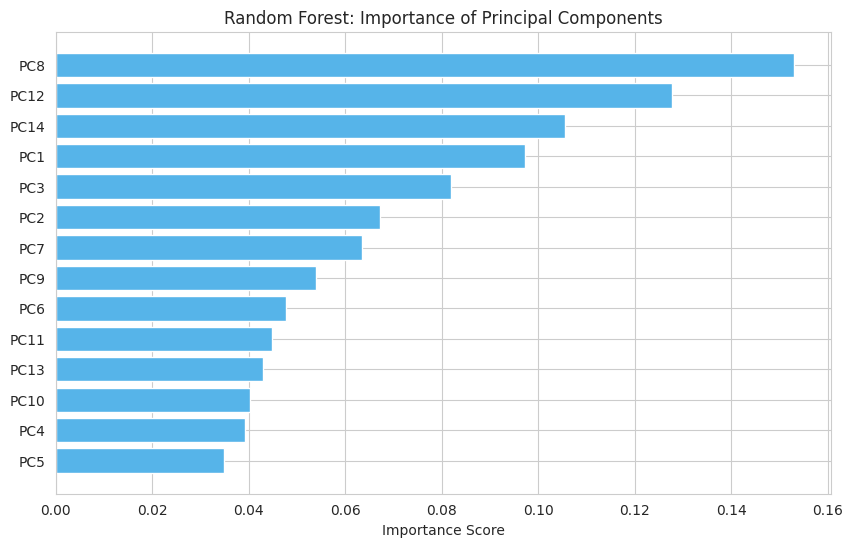

-----------------------------------------------------------------
TOP 5 BIOMARKERS COMPOSING THE KEY COMPONENTS
-----------------------------------------------------------------

>>> PC8 (Importance Rank: 1):
    [+] central_meanfreq_beta_mean               (0.286)
    [+] parietal_meanfreq_alpha_mean             (0.271)
    [-] frontal_meanfreq_theta_slope             (-0.263)
    [+] frontal_meanfreq_delta_slope             (0.257)
    [+] frontal_meanfreq_total_slope             (0.222)

>>> PC12 (Importance Rank: 2):
    [+] frontal_ratio_alpha_theta_over_beta_mean (0.356)
    [+] parietal_meanfreq_delta_slope            (0.292)
    [-] frontal_meanfreq_alpha_mean              (-0.285)
    [-] parietal_meanfreq_theta_slope            (-0.254)
    [-] parietal_meanfreq_alpha_mean             (-0.247)

>>> PC14 (Importance Rank: 3):
    [+] frontal_alpha_asymmetry_mean             (0.464)
    [-] frontal_meanfreq_theta_mean              (-0.296)
    [-] central_meanfreq_total_slope  

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc

# 1. Feature Selection & Binary Labeling
# Using the broad set: includes ratios, complex ratios, meanfreq, and asymmetry
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']
selected_biomarkers = [col for col in data.columns if any(term in col for term in include_terms)]

df_bin = data.copy()
# Binary Target: 1 for ChatGPT, 0 for Search/Brain-only
df_bin['binary_label'] = df_bin['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)

X_raw = df_bin[selected_biomarkers]
y = df_bin['binary_label']
groups = df_bin['subject_id']

# 2. Subject-Wise Normalization (The Accuracy Booster)
# This centers each person's data around their own average
X_norm = X_raw.groupby(groups).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 3. PCA on Normalized Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

# Keep at least 6 components for the requested PC3 vs PC6 analysis
pca_full = PCA().fit(X_scaled)
n_comp = max(6, np.sum(pca_full.explained_variance_ > 1))
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_scaled)

pc_names = [f'PC{i+1}' for i in range(n_comp)]

# 4. Random Forest with Group Cross-Validation
gkf = GroupKFold(n_splits=5)
train_accs, test_accs, auc_scores = [], [], []
all_importances = []

print(f"Training Binary PCA-Random Forest on {n_comp} components...")

for tr_idx, te_idx in gkf.split(X_pca, y, groups=groups):
    rf = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=5,
                                class_weight='balanced', random_state=42)
    rf.fit(X_pca[tr_idx], y[tr_idx])

    train_accs.append(rf.score(X_pca[tr_idx], y[tr_idx]))
    test_accs.append(rf.score(X_pca[te_idx], y[te_idx]))
    auc_scores.append(roc_auc_score(y[te_idx], rf.predict_proba(X_pca[te_idx])[:, 1]))
    all_importances.append(rf.feature_importances_)

# --- VISUALIZATIONS ---
sns.set_style("whitegrid")
custom_palette = {1: "#E69F00", 0: "#56B4E9"} # Gold vs Steel Blue

# Plot 1: PCA Cross-Sections (PC3/1 and PC3/6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
pca_df = pd.DataFrame(X_pca, columns=pc_names)
pca_df['Task'] = y

sns.scatterplot(data=pca_df, x='PC3', y='PC1', hue='Task', palette=custom_palette, s=100, edgecolor='w', alpha=0.7, ax=ax1)
ax1.set_title("PCA: PC3 vs PC1")

sns.scatterplot(data=pca_df, x='PC3', y='PC6', hue='Task', palette=custom_palette, s=100, edgecolor='w', alpha=0.7, ax=ax2)
ax2.set_title("PCA: PC3 vs PC6")
plt.show()

# Plot 2: Component Importance (Which PC drives the binary decision?)
mean_imp = np.mean(all_importances, axis=0)
indices = np.argsort(mean_imp)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), mean_imp[indices], color='#56B4E9')
plt.yticks(range(len(indices)), [pc_names[i] for i in indices])
plt.title('Random Forest: Importance of Principal Components')
plt.xlabel('Importance Score')
plt.show()

# --- ANALYSIS: LOADINGS & ACCURACY ---
print("-" * 65)
print("TOP 5 BIOMARKERS COMPOSING THE KEY COMPONENTS")
print("-" * 65)
loadings = pd.DataFrame(pca.components_.T, columns=pc_names, index=selected_biomarkers)

# We report on the top 3 most important components from the Random Forest
top_pcs_idx = np.argsort(mean_imp)[-3:][::-1]
for i in top_pcs_idx:
    pc = pc_names[i]
    print(f"\n>>> {pc} (Importance Rank: {list(indices[::-1]).index(i)+1}):")
    top_5 = loadings[pc].abs().sort_values(ascending=False).head(5)
    for feat, val in top_5.items():
        weight = loadings.loc[feat, pc]
        print(f"    {'[+]' if weight > 0 else '[-]'} {feat:40} ({weight:.3f})")

print("\n" + "="*45)
print(f"Mean Training Accuracy: {np.mean(train_accs)*100:.2f}%")
print(f"Mean Testing Accuracy:  {np.mean(test_accs)*100:.2f}%")
print(f"Mean ROC-AUC:           {np.mean(auc_scores):.2f}")
print("="*45)

Region       | Feats Kept | Train Acc  | Test Acc  
-------------------------------------------------------
Central      | 10         |    93.75% |    73.33%
Frontal      | 10         |    96.25% |    71.67%
Parietal     | 10         |    94.58% |    70.00%


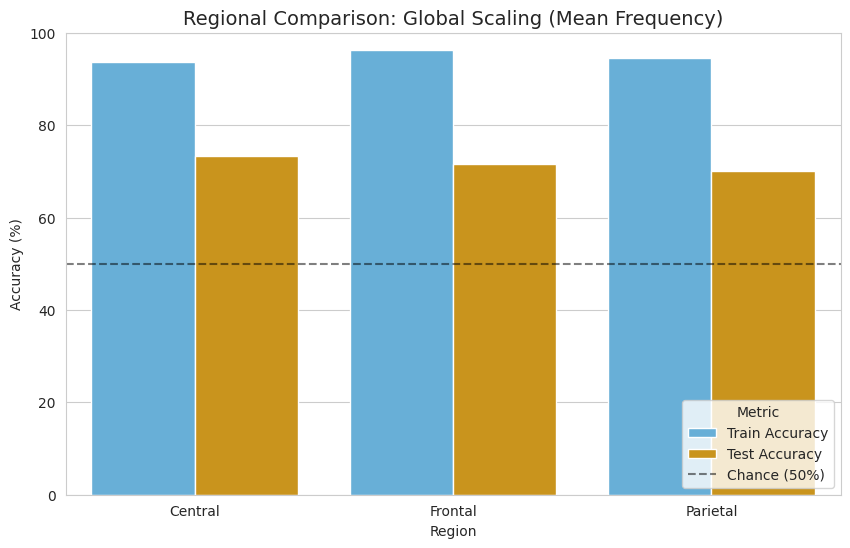

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Setup and Regions
regions = ['central', 'frontal', 'parietal']
results = []

# Prepare Binary Labels
data_bin = data.copy()
data_bin['binary_label'] = data_bin['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
y = data_bin['binary_label']
groups = data_bin['subject_id']

print(f"{'Region':<12} | {'Feats Kept':<10} | {'Train Acc':<10} | {'Test Acc':<10}")
print("-" * 55)

for region in regions:
    # A. Filter for region and meanfreq
    region_cols = [col for col in data.columns if region in col.lower() and 'meanfreq' in col.lower()]
    X_raw = data_bin[region_cols]

    # B. GLOBAL SCALING (Replacing Subject-Wise Norm)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=region_cols)

    # C. Prune Redundant Features (|r| > 0.90)
    # We prune based on the globally scaled correlations
    corr_matrix = X_scaled.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
    X_filtered = X_scaled.drop(columns=to_drop)

    # D. Random Forest with GroupKFold
    gkf = GroupKFold(n_splits=5)
    tr_accs, te_accs = [], []

    for tr_idx, te_idx in gkf.split(X_filtered, y, groups=groups):
        rf = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=5,
                                    class_weight='balanced', random_state=42)
        rf.fit(X_filtered.iloc[tr_idx], y.iloc[tr_idx])
        tr_accs.append(rf.score(X_filtered.iloc[tr_idx], y.iloc[tr_idx]))
        te_accs.append(rf.score(X_filtered.iloc[te_idx], y.iloc[te_idx]))

    avg_train = np.mean(tr_accs) * 100
    avg_test = np.mean(te_accs) * 100

    results.append({
        'Region': region.capitalize(),
        'Features Kept': len(X_filtered.columns),
        'Train Accuracy': avg_train,
        'Test Accuracy': avg_test
    })

    print(f"{region.capitalize():<12} | {len(X_filtered.columns):<10} | {avg_train:>8.2f}% | {avg_test:>8.2f}%")

# --- VISUALIZATION ---
res_df = pd.DataFrame(results).melt(id_vars='Region', value_vars=['Train Accuracy', 'Test Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(data=res_df, x='Region', y='value', hue='variable',
            palette={'Train Accuracy': '#56B4E9', 'Test Accuracy': '#E69F00'})

plt.ylim(0, 100)
plt.axhline(50, color='black', linestyle='--', alpha=0.5, label='Chance (50%)')
plt.title('Regional Comparison: Global Scaling (Mean Frequency)', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.legend(title='Metric', loc='lower right')
plt.show()

Region       | Feats  | Train Acc  | Test Acc  
--------------------------------------------------
Frontal      | 18     |    97.50% |    73.33%
Central      | 16     |    93.33% |    78.33%
Parietal     | 20     |    95.83% |    68.33%


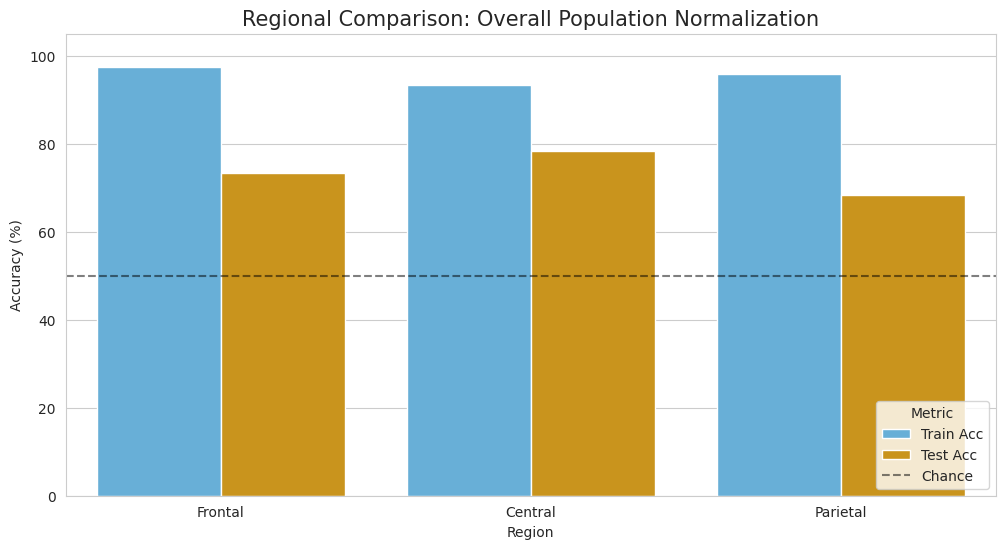

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Configuration
regions = ['frontal', 'central', 'parietal', 'occipital', 'temporal']
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']

# Prepare Labels
df_all = data.copy()
df_all['binary_label'] = df_all['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
y = df_all['binary_label']
groups = df_all['subject_id']

region_results = []

print(f"{'Region':<12} | {'Feats':<6} | {'Train Acc':<10} | {'Test Acc':<10}")
print("-" * 50)

# 2. Loop through every region using Overall Normalization
for region in regions:
    # Filter for biomarkers within the specific region
    reg_cols = [col for col in data.columns if region in col.lower() and
                any(term in col.lower() for term in include_terms)]

    if len(reg_cols) == 0: continue

    X_raw = df_all[reg_cols]

    # --- GLOBAL SCALING (OVERALL NORMALIZATION) ---
    # This replaces the within-subject groupby transformation
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=reg_cols)

    # Prune Redundant Features (|r| > 0.90)
    corr_matrix = X_scaled.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
    X_filtered = X_scaled.drop(columns=to_drop)

    # Random Forest with Group Cross-Validation
    # GroupKFold ensures we still test on unseen subjects
    gkf = GroupKFold(n_splits=5)
    tr_accs, te_accs = [], []

    for tr_idx, te_idx in gkf.split(X_filtered, y, groups=groups):
        rf = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=5,
                                    class_weight='balanced', random_state=42)
        rf.fit(X_filtered.iloc[tr_idx], y.iloc[tr_idx])
        tr_accs.append(rf.score(X_filtered.iloc[tr_idx], y.iloc[tr_idx]))
        te_accs.append(rf.score(X_filtered.iloc[te_idx], y.iloc[te_idx]))

    avg_train = np.mean(tr_accs) * 100
    avg_test = np.mean(te_accs) * 100

    region_results.append({
        'Region': region.capitalize(),
        'Features': len(X_filtered.columns),
        'Train Acc': avg_train,
        'Test Acc': avg_test
    })

    print(f"{region.capitalize():<12} | {len(X_filtered.columns):<6} | {avg_train:>8.2f}% | {avg_test:>8.2f}%")

# 3. Final Comparison Plot
res_df = pd.DataFrame(region_results).melt(id_vars='Region', value_vars=['Train Acc', 'Test Acc'])

plt.figure(figsize=(12, 6))
sns.barplot(data=res_df, x='Region', y='value', hue='variable',
            palette={'Train Acc': '#56B4E9', 'Test Acc': '#E69F00'}) # Steel Blue & Gold

plt.axhline(50, color='black', linestyle='--', alpha=0.5, label='Chance')
plt.title('Regional Comparison: Overall Population Normalization', fontsize=15)
plt.ylabel('Accuracy (%)')
plt.legend(title='Metric', loc='lower right')
plt.ylim(0, 105)
plt.show()

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Configuration
regions = ['frontal', 'central', 'parietal', 'occipital', 'temporal']
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']

# Prepare Labels for Training Data
y_train = data['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
# Prepare Labels for Safe Data
y_safe = the_safe['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)

safe_test_results = []

print(f"{'Region':<12} | {'Feats':<6} | {'Train Acc':<10} | {'Safe Test Acc':<12}")
print("-" * 55)

for region in regions:
    # Filter columns for this specific region
    reg_cols = [col for col in data.columns if region in col.lower() and
                any(term in col.lower() for term in include_terms)]

    if len(reg_cols) == 0: continue

    # --- GLOBAL SCALING (POPULATION-WIDE) ---
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(data[reg_cols]), columns=reg_cols)
    X_safe_scaled = pd.DataFrame(scaler.transform(the_safe[reg_cols]), columns=reg_cols)

    # Prune Redundant Features (|r| > 0.90) based on Training Set
    corr_matrix = X_train_scaled.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

    X_tr_filtered = X_train_scaled.drop(columns=to_drop)
    X_safe_filtered = X_safe_scaled.drop(columns=to_drop)

    # Train Random Forest on the FULL training set
    rf = RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=5,
                                class_weight='balanced', random_state=42)
    rf.fit(X_tr_filtered, y_train)

    # Evaluate
    tr_acc = rf.score(X_tr_filtered, y_train) * 100
    safe_acc = accuracy_score(y_safe, rf.predict(X_safe_filtered)) * 100

    safe_test_results.append({
        'Region': region.capitalize(),
        'Safe Acc': safe_acc
    })

    print(f"{region.capitalize():<12} | {len(X_tr_filtered.columns):<6} | {tr_acc:>8.2f}% | {safe_acc:>8.2f}%")

print("-" * 55)

Region       | Feats  | Train Acc  | Safe Test Acc
-------------------------------------------------------
Frontal      | 18     |    98.33% |    75.00%
Central      | 16     |    93.33% |    62.50%
Parietal     | 20     |    96.67% |    75.00%
-------------------------------------------------------


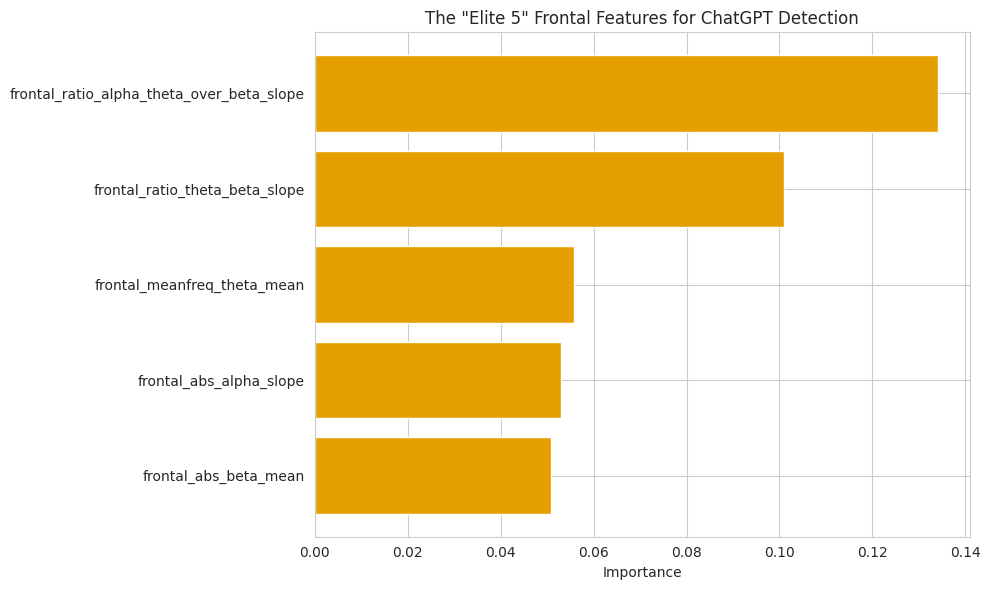

---------------------------------------------
Features Kept: ['frontal_abs_beta_mean', 'frontal_abs_alpha_slope', 'frontal_meanfreq_theta_mean', 'frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']
---------------------------------------------
Mean Training Accuracy (5-Feat): 92.50%
Mean Testing Accuracy (5-Feat):  86.67%
---------------------------------------------


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score

# 1. Isolate Frontal Features (All Biomarker Types)
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']
frontal_cols = [col for col in data.columns if 'frontal' in col.lower() and
                any(term in col.lower() for term in include_terms)]

df_final = data[['label', 'subject_id'] + frontal_cols].copy()
df_final['binary_label'] = df_final['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)

X_raw = df_final[frontal_cols]
y = df_final['binary_label']
groups = df_final['subject_id']

# 2. Subject-Wise Normalization
X_norm = X_raw.groupby(groups).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 3. Feature Selection: Identifying the "Elite 5"
# We run a quick pass to find which features actually matter
selector_rf = RandomForestClassifier(n_estimators=500, random_state=42)
selector_rf.fit(X_norm, y)
importances = selector_rf.feature_importances_
top_5_indices = np.argsort(importances)[-5:]
top_5_features = X_norm.columns[top_5_indices].tolist()

X_top5 = X_norm[top_5_features]

# 4. Final Evaluation with Restricted Feature Set
gkf = GroupKFold(n_splits=5)
train_accs, test_accs = [], []

for tr_idx, te_idx in gkf.split(X_top5, y, groups=groups):
    rf = RandomForestClassifier(n_estimators=500, max_depth=3, # Shallower for 5 features
                                min_samples_leaf=5, class_weight='balanced',
                                random_state=42)
    rf.fit(X_top5.iloc[tr_idx], y.iloc[tr_idx])
    train_accs.append(rf.score(X_top5.iloc[tr_idx], y.iloc[tr_idx]))
    test_accs.append(rf.score(X_top5.iloc[te_idx], y.iloc[te_idx]))

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.barh(top_5_features, sorted(importances[top_5_indices]), color='#E69F00') # Gold
plt.title('The "Elite 5" Frontal Features for ChatGPT Detection')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# --- RESULTS ---
print("-" * 45)
print(f"Features Kept: {top_5_features}")
print("-" * 45)
print(f"Mean Training Accuracy (5-Feat): {np.mean(train_accs)*100:.2f}%")
print(f"Mean Testing Accuracy (5-Feat):  {np.mean(test_accs)*100:.2f}%")
print("-" * 45)

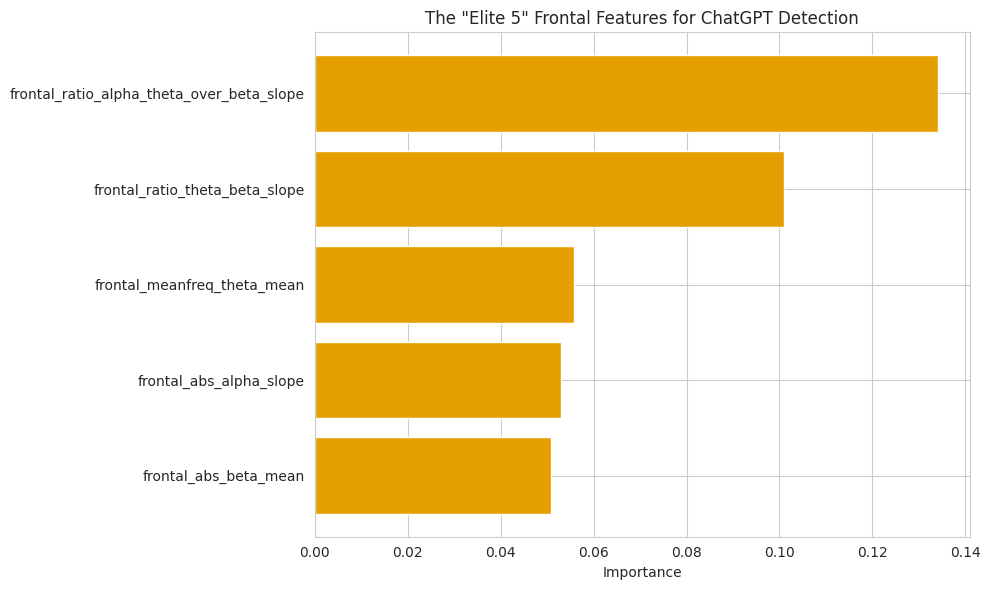

---------------------------------------------
Features Kept: ['frontal_abs_beta_mean', 'frontal_abs_alpha_slope', 'frontal_meanfreq_theta_mean', 'frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']
---------------------------------------------
Mean Training Accuracy (5-Feat): 92.50%
Mean Testing Accuracy (5-Feat):  86.67%
---------------------------------------------


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score

# 1. Isolate Frontal Features (All Biomarker Types)
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']
frontal_cols = [col for col in data.columns if 'frontal' in col.lower() and
                any(term in col.lower() for term in include_terms)]

df_final = data[['label', 'subject_id'] + frontal_cols].copy()
df_final['binary_label'] = df_final['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)

X_raw = df_final[frontal_cols]
y = df_final['binary_label']
groups = df_final['subject_id']

# 2. Subject-Wise Normalization
X_norm = X_raw.groupby(groups).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 3. Feature Selection: Identifying the "Elite 5"
# We run a quick pass to find which features actually matter
selector_rf = RandomForestClassifier(n_estimators=500, random_state=42)
selector_rf.fit(X_norm, y)
importances = selector_rf.feature_importances_
top_5_indices = np.argsort(importances)[-5:]
top_5_features = X_norm.columns[top_5_indices].tolist()

X_top5 = X_norm[top_5_features]

# 4. Final Evaluation with Restricted Feature Set
gkf = GroupKFold(n_splits=5)
train_accs, test_accs = [], []

for tr_idx, te_idx in gkf.split(X_top5, y, groups=groups):
    rf = RandomForestClassifier(n_estimators=500, max_depth=3, # Shallower for 5 features
                                min_samples_leaf=5, class_weight='balanced',
                                random_state=42)
    rf.fit(X_top5.iloc[tr_idx], y.iloc[tr_idx])
    train_accs.append(rf.score(X_top5.iloc[tr_idx], y.iloc[tr_idx]))
    test_accs.append(rf.score(X_top5.iloc[te_idx], y.iloc[te_idx]))

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.barh(top_5_features, sorted(importances[top_5_indices]), color='#E69F00') # Gold
plt.title('The "Elite 5" Frontal Features for ChatGPT Detection')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# --- RESULTS ---
print("-" * 45)
print(f"Features Kept: {top_5_features}")
print("-" * 45)
print(f"Mean Training Accuracy (5-Feat): {np.mean(train_accs)*100:.2f}%")
print(f"Mean Testing Accuracy (5-Feat):  {np.mean(test_accs)*100:.2f}%")
print("-" * 45)

--------------------------------------------------
MODEL SETTINGS: Frontal Region | Top 2 Features | Subject-Normalized
--------------------------------------------------
Features Used: ['frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']
--------------------------------------------------
MEAN TRAINING ACCURACY: 95.83%
MEAN TESTING ACCURACY:  86.67%
--------------------------------------------------


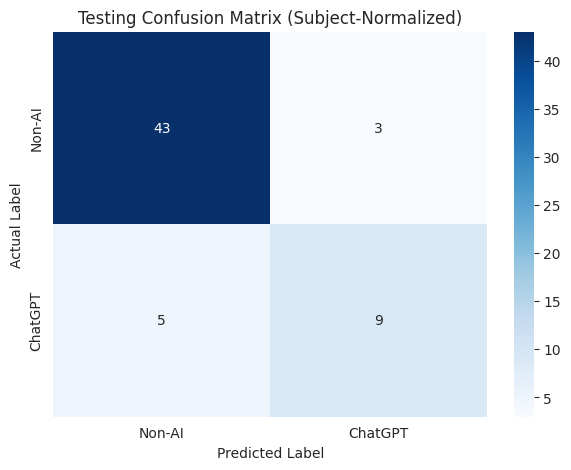

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix

# 1. Feature Selection (Frontal Only)
include_terms = ['ratio_theta_beta', '_ratio_alpha_theta_over_beta', 'meanfreq', 'asymmetry', 'abs']
frontal_cols = [col for col in data.columns if 'frontal' in col.lower() and
                any(term in col.lower() for term in include_terms)]

X_raw = data[frontal_cols]
y = data['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups = data['subject_id']

# 2. WITHIN-SUBJECT NORMALIZATION (Already correctly implemented here)
X_norm = X_raw.groupby(groups).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 3. Identify the "Elite 2" Features
selector = RandomForestClassifier(n_estimators=500, random_state=42)
selector.fit(X_norm, y)
top_2_idx = np.argsort(selector.feature_importances_)[-2:]
top_2_features = X_norm.columns[top_2_idx].tolist()

X_top2 = X_norm[top_2_features]

# 4. Cross-Validation with Confusion Matrix Tracking
gkf = GroupKFold(n_splits=5)
train_accs = []
test_accs = []
all_actuals = []
all_preds = []

for tr_idx, te_idx in gkf.split(X_top2, y, groups=groups):
    rf = RandomForestClassifier(n_estimators=500, max_depth=3,
                                class_weight='balanced', random_state=42)

    rf.fit(X_top2.iloc[tr_idx], y.iloc[tr_idx])

    # Accuracies
    train_accs.append(rf.score(X_top2.iloc[tr_idx], y.iloc[tr_idx]))
    test_accs.append(rf.score(X_top2.iloc[te_idx], y.iloc[te_idx]))

    # Collect data for Confusion Matrix
    all_actuals.extend(y.iloc[te_idx])
    all_preds.extend(rf.predict(X_top2.iloc[te_idx]))

# --- OUTPUT ---
print("-" * 50)
print(f"MODEL SETTINGS: Frontal Region | Top 2 Features | Subject-Normalized")
print("-" * 50)
print(f"Features Used: {top_2_features}")
print("-" * 50)
print(f"MEAN TRAINING ACCURACY: {np.mean(train_accs)*100:.2f}%")
print(f"MEAN TESTING ACCURACY:  {np.mean(test_accs)*100:.2f}%")
print("-" * 50)

# --- CONFUSION MATRIX ---
cm = confusion_matrix(all_actuals, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-AI', 'ChatGPT'],
            yticklabels=['Non-AI', 'ChatGPT'])
plt.title('Testing Confusion Matrix (Subject-Normalized)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

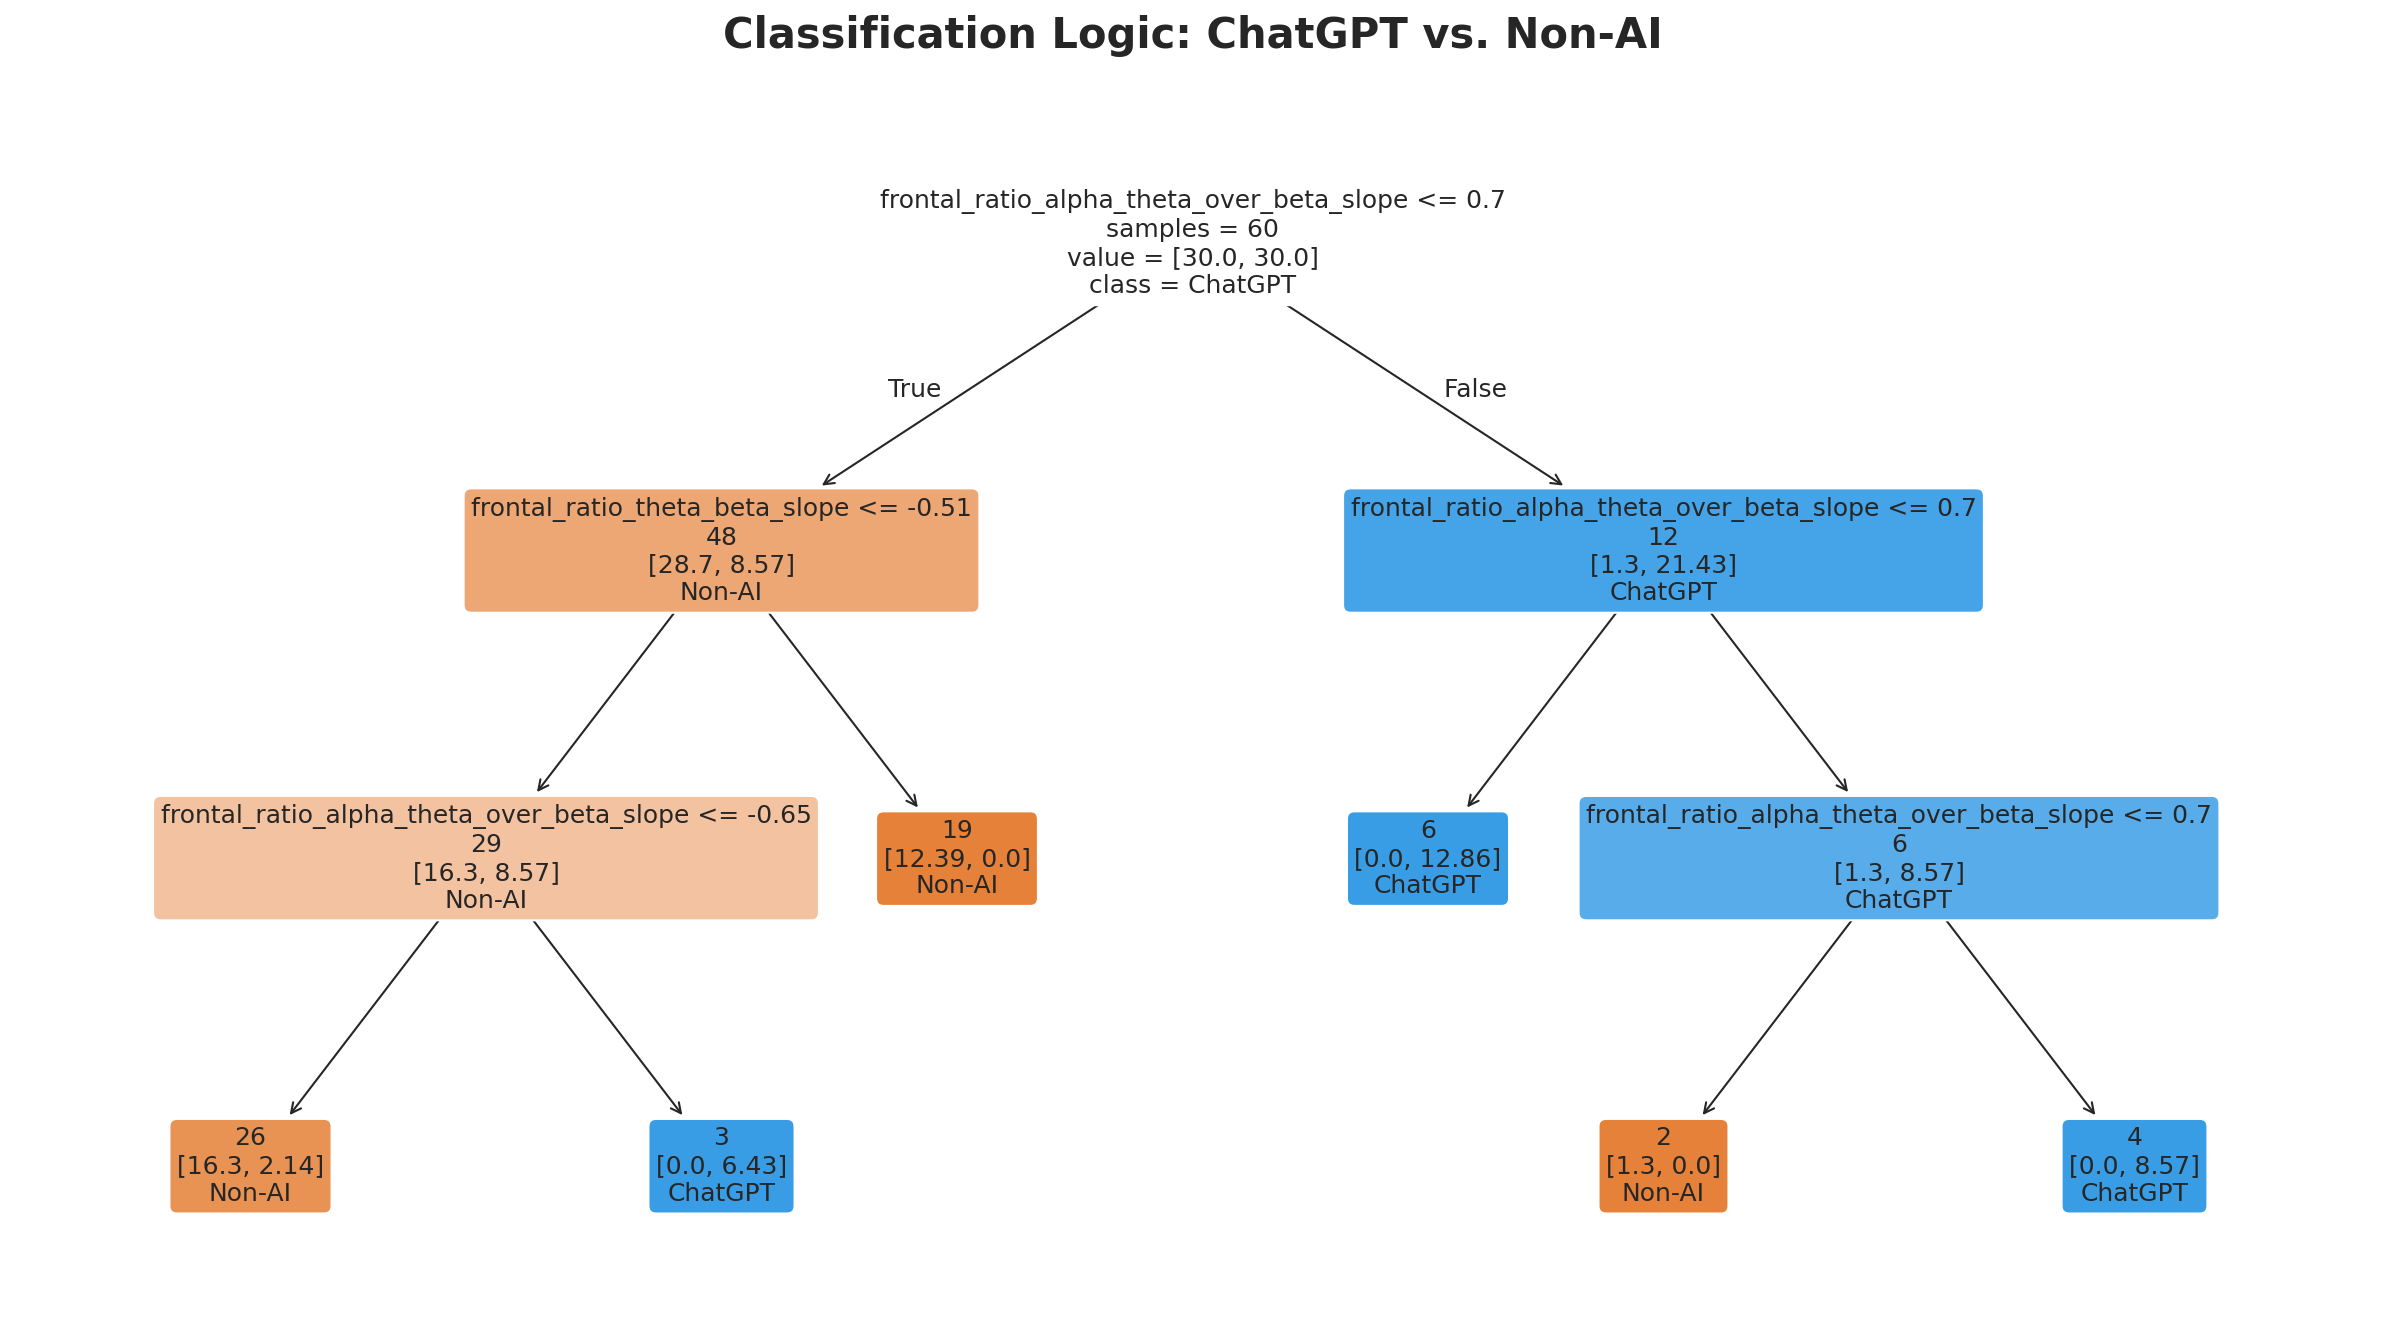

In [24]:
from sklearn.tree import plot_tree

# 1. Initialize and Fit (Using your existing X_top2 and y)
dt_slide = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_slide.fit(X_top2, y)

# 2. Plotting with "Slide-Safe" settings
plt.figure(figsize=(16, 9), dpi=150) # High resolution for copy-pasting

# We hide Gini and use 'impurity=False' to clean up the boxes
plot_tree(dt_slide,
          feature_names=top_2_features,
          class_names=['Non-AI', 'ChatGPT'],
          filled=True,
          rounded=True,
          precision=2,        # Rounds decimals for cleaner logic
          impurity=False,     # REMOVES GINI (Cleanest look)
          proportion=False,   # Keeps raw sample counts
          fontsize=12,
          label='root')       # Labels only the top of each node

plt.title("Classification Logic: ChatGPT vs. Non-AI", fontsize=20, pad=20, fontweight='bold')
plt.tight_layout()

# Save as a clean image for direct use
plt.savefig("decision_tree_presentation.png", bbox_inches='tight', transparent=True)
plt.show()

In [25]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Paste your copied path between the quotes
file_path = '/content/drive/MyDrive/Final project/window.csv' #Create Final project folder in own drive and upload data there

full_data = pd.read_csv(file_path)

# Verify the data is there
#print(f"Dataset loaded with {full_data.shape[0]} rows and {full_data.shape[1]} columns.")
full_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,subject_id,task_desc,label,fif_path,segment_index,window_index_within_segment,window_index_within_task,segment_start_sec,segment_end_sec,window_start_sec,...,parietal_rel_beta,parietal_meanfreq_beta,parietal_ratio_theta_beta,parietal_ratio_theta_alpha,parietal_ratio_alpha_theta,parietal_ratio_beta_alpha,parietal_ratio_beta_over_alpha_theta,parietal_ratio_alpha_theta_over_beta,parietal_spectral_entropy,frontal_alpha_asymmetry
0,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,0,0,609.470093,914.5,609.470093,...,0.063490,20.012158,0.138750,0.138008,0.124567,0.120711,0.106072,0.265483,2.295700,0.006270
1,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,1,1,609.470093,914.5,614.470093,...,0.061907,19.609555,0.132792,0.137237,0.084346,0.121933,0.107219,0.218387,2.305581,-0.011152
2,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,2,2,609.470093,914.5,619.470093,...,0.073136,19.091544,0.627279,0.663865,0.253875,0.395212,0.237527,0.945600,2.612668,0.261782
3,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,3,3,609.470093,914.5,624.470093,...,0.035172,20.377158,0.335328,0.359440,0.110941,0.207663,0.152756,0.461979,1.930554,0.011805
4,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,4,4,609.470093,914.5,629.470093,...,0.095617,21.866165,0.258603,0.323264,0.123408,0.395400,0.298807,0.374890,2.361450,0.074311


Calculating neural slopes per session...


/tmp/ipykernel_5741/3662111544.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_summaries = full_data.groupby(['subject_id', 'task_desc', 'label']).apply(


Testing on the first 5 minutes of each task...
--------------------------------------------------
5-MINUTE SLOPE ACCURACY: 55.88%
--------------------------------------------------


/tmp/ipykernel_5741/3662111544.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_summaries = df_5min.groupby(['subject_id', 'task_desc', 'label']).apply(


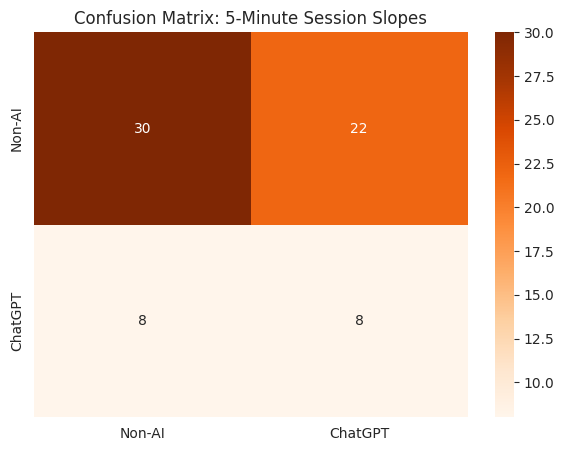

    subject_id task_desc       label Predicted
0            3     Task1  brain_only   ChatGPT
1            3     Task2     chatgpt    Non-AI
2            5     Task1  brain_only    Non-AI
3            5     Task2      search    Non-AI
4            6     Task1  brain_only   ChatGPT
..         ...       ...         ...       ...
63          80     Task2      search   ChatGPT
64          82     Task1  brain_only    Non-AI
65          82     Task2     chatgpt   ChatGPT
66          83     Task1  brain_only   ChatGPT
67          83     Task2      search    Non-AI

[68 rows x 4 columns]


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import linregress

# 1. DEFINE SLOPE CALCULATION FUNCTION
def get_slope(y):
    """Calculates the linear regression slope of a series."""
    if len(y) < 2: return 0
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

# 2. FEATURE GENERATION: Create the 'Slope' features for the whole dataset
# We group by subject and task to find the slope of each specific session
print("Calculating neural slopes per session...")
target_base = ['frontal_ratio_theta_beta', 'frontal_ratio_alpha_theta_over_beta']

# This creates a summarized dataset with 1 row per subject/task
session_summaries = full_data.groupby(['subject_id', 'task_desc', 'label']).apply(
    lambda df: pd.Series({
        'frontal_ratio_theta_beta_slope': get_slope(df['frontal_ratio_theta_beta']),
        'frontal_ratio_alpha_theta_over_beta_slope': get_slope(df['frontal_ratio_alpha_theta_over_beta'])
    })
).reset_index()

# 3. PREPARE TRAINING DATA
top_2_features = ['frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']
X_raw = session_summaries[top_2_features]
y = session_summaries['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups = session_summaries['subject_id']

# Within-Subject Normalization
X_norm = X_raw.groupby(groups).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 4. TRAIN FINAL MODEL
final_rf = RandomForestClassifier(n_estimators=500, max_depth=3, class_weight='balanced', random_state=42)
final_rf.fit(X_norm, y)

# 5. TEST ON THE FIRST 5 MINUTES (60 ROWS) ONLY
# We do the same process but only on the first 60 rows of each session
print("Testing on the first 5 minutes of each task...")
df_5min = full_data.groupby(['subject_id', 'task_desc']).head(60)

test_summaries = df_5min.groupby(['subject_id', 'task_desc', 'label']).apply(
    lambda df: pd.Series({
        'frontal_ratio_theta_beta_slope': get_slope(df['frontal_ratio_theta_beta']),
        'frontal_ratio_alpha_theta_over_beta_slope': get_slope(df['frontal_ratio_alpha_theta_over_beta'])
    })
).reset_index()

X_test_raw = test_summaries[top_2_features]
y_test = test_summaries['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
test_groups = test_summaries['subject_id']

# Normalize the test snapshots
X_test_norm = X_test_raw.groupby(test_groups).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 6. PREDICT & EVALUATE
y_pred = final_rf.predict(X_test_norm)
acc = accuracy_score(y_test, y_pred)

# --- VISUALIZATION ---
print("-" * 50)
print(f"5-MINUTE SLOPE ACCURACY: {acc*100:.2f}%")
print("-" * 50)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-AI', 'ChatGPT'], yticklabels=['Non-AI', 'ChatGPT'])
plt.title('Confusion Matrix: 5-Minute Session Slopes')
plt.show()

# Individual Result List
test_summaries['Predicted'] = pd.Series(y_pred).map({1: 'ChatGPT', 0: 'Non-AI'}).values
print(test_summaries[['subject_id', 'task_desc', 'label', 'Predicted']])

Calculating session averages for training...
Testing on the first 5 minutes (means) of each task...
--------------------------------------------------
5-MINUTE MEAN ACCURACY: 75.00%
--------------------------------------------------


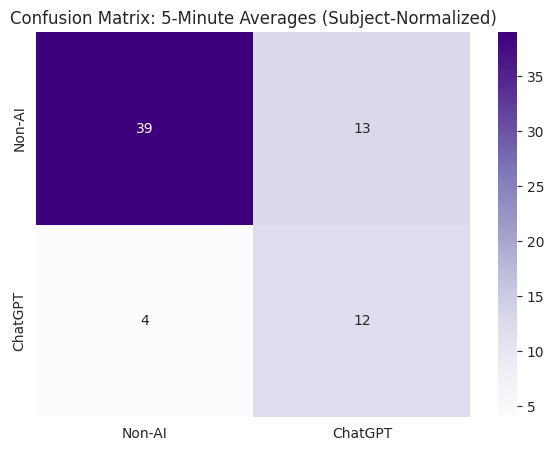

    subject_id task_desc       label Predicted
0            3     Task1  brain_only    Non-AI
1            3     Task2     chatgpt   ChatGPT
2            5     Task1  brain_only    Non-AI
3            5     Task2      search    Non-AI
4            6     Task1  brain_only    Non-AI
..         ...       ...         ...       ...
63          80     Task2      search   ChatGPT
64          82     Task1  brain_only    Non-AI
65          82     Task2     chatgpt   ChatGPT
66          83     Task1  brain_only    Non-AI
67          83     Task2      search   ChatGPT

[68 rows x 4 columns]


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. DEFINE THE TARGET BASE FEATURES
target_features = ['frontal_ratio_theta_beta', 'frontal_ratio_alpha_theta_over_beta']

# 2. FEATURE GENERATION: Create the 'Mean' features for the whole dataset
# We calculate the average of each feature for every unique session (subject + task)
print("Calculating session averages for training...")
session_means = full_data.groupby(['subject_id', 'task_desc', 'label'])[target_features].mean().reset_index()

# 3. PREPARE TRAINING DATA
X_train_raw = session_means[target_features]
y_train = session_means['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups_train = session_means['subject_id']

# Subject-Wise Normalization (Ensures the model compares 'Search Mean' vs 'Chat Mean' for the same person)
X_train_norm = X_train_raw.groupby(groups_train).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 4. TRAIN THE FINAL MODEL ON SESSION MEANS
final_rf_means = RandomForestClassifier(n_estimators=500, max_depth=3,
                                        class_weight='balanced', random_state=42)
final_rf_means.fit(X_train_norm, y_train)

# 5. ISOLATE AND TEST ON THE FIRST 5 MINUTES (60 ROWS) ONLY
print("Testing on the first 5 minutes (means) of each task...")
df_5min = full_data.groupby(['subject_id', 'task_desc']).head(60)

# Calculate means for just that 5-minute window
test_means = df_5min.groupby(['subject_id', 'task_desc', 'label'])[target_features].mean().reset_index()

X_test_raw = test_means[target_features]
y_test = test_means['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups_test = test_means['subject_id']

# Normalize the test snapshots
X_test_norm = X_test_raw.groupby(groups_test).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 6. PREDICT & EVALUATE
y_pred = final_rf_means.predict(X_test_norm)
acc = accuracy_score(y_test, y_pred)

# --- VISUALIZATION ---
print("-" * 50)
print(f"5-MINUTE MEAN ACCURACY: {acc*100:.2f}%")
print("-" * 50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-AI', 'ChatGPT'], yticklabels=['Non-AI', 'ChatGPT'])
plt.title('Confusion Matrix: 5-Minute Averages (Subject-Normalized)')
plt.show()

# Individual Result Table
test_means['Predicted'] = pd.Series(y_pred).map({1: 'ChatGPT', 0: 'Non-AI'}).values
print(test_means[['subject_id', 'task_desc', 'label', 'Predicted']])

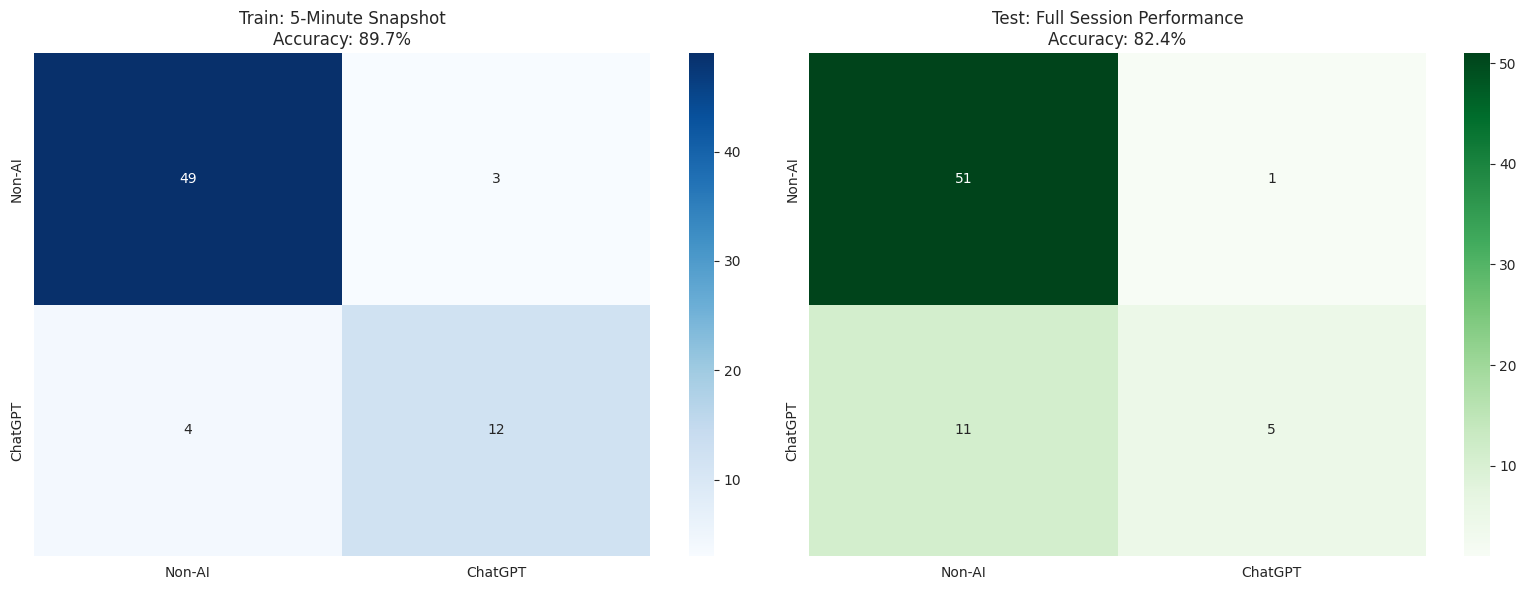

Accuracy using 5-Min Means: 89.71%
Accuracy using Full Session: 82.35%


In [28]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARE THE TWO MEAN-BASED DATASETS
target_features = ['frontal_ratio_theta_beta', 'frontal_ratio_alpha_theta_over_beta']

# --- A. The 5-Minute Snapshot (Training Data) ---
df_5min = full_data.groupby(['subject_id', 'task_desc']).head(60)
train_df = df_5min.groupby(['subject_id', 'task_desc', 'label'])[target_features].mean().reset_index()

# --- B. The Full Session (Test Data) ---
test_df = full_data.groupby(['subject_id', 'task_desc', 'label'])[target_features].mean().reset_index()

# 2. DEFINE FEATURES AND LABELS
X_train_raw = train_df[target_features]
y_train = train_df['label'].apply(lambda x: 1 if 'chat' in str(x).lower() else 0)

X_test_raw = test_df[target_features]
y_test = test_df['label'].apply(lambda x: 1 if 'chat' in str(x).lower() else 0)

# 3. SUBJECT-WISE NORMALIZATION
# We normalize both sets relative to the subjects' own baseline in that specific window
X_train_norm = X_train_raw.groupby(train_df['subject_id']).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
X_test_norm = X_test_raw.groupby(test_df['subject_id']).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 4. TRAIN THE RANDOM FOREST
# We use the 5-minute data to "teach" the model
rf_model = RandomForestClassifier(n_estimators=500, max_depth=3, class_weight='balanced', random_state=42)
rf_model.fit(X_train_norm, y_train)

# 5. PREDICT ON BOTH
train_preds = rf_model.predict(X_train_norm)
test_preds = rf_model.predict(X_test_norm)

# 6. VISUALIZE COMPARISON
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix: Training (5-Min)
cm_train = confusion_matrix(y_train, train_preds)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-AI', 'ChatGPT'], yticklabels=['Non-AI', 'ChatGPT'])
axes[0].set_title(f"Train: 5-Minute Snapshot\nAccuracy: {accuracy_score(y_train, train_preds)*100:.1f}%")

# Confusion Matrix: Testing (Full Session)
cm_test = confusion_matrix(y_test, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Non-AI', 'ChatGPT'], yticklabels=['Non-AI', 'ChatGPT'])
axes[1].set_title(f"Test: Full Session Performance\nAccuracy: {accuracy_score(y_test, test_preds)*100:.1f}%")

plt.tight_layout()
plt.show()

# Print Numerical Comparison
print(f"Accuracy using 5-Min Means: {accuracy_score(y_train, train_preds)*100:.2f}%")
print(f"Accuracy using Full Session: {accuracy_score(y_test, test_preds)*100:.2f}%")

In [29]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. PREPARE DATA
target_features = ['frontal_ratio_theta_beta', 'frontal_ratio_alpha_theta_over_beta']

# Get Full Session Means
full_means = full_data.groupby(['subject_id', 'task_desc', 'label'])[target_features].mean().reset_index()

# Get 5-Minute Snapshot Means
five_min_df = full_data.groupby(['subject_id', 'task_desc']).head(60)
five_min_means = five_min_df.groupby(['subject_id', 'task_desc', 'label'])[target_features].mean().reset_index()

def calculate_cohens_d(group1, group2):
    """Calculates Cohen's d for effect size."""
    diff = group1.mean() - group2.mean()
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return diff / pooled_std

# 2. CALCULATION LOOP
stats_report = []

for feat in target_features:
    for source_name, df in [("Full Session", full_means), ("5-Minute Snapshot", five_min_means)]:
        chat = df[df['label'].str.contains('chat', case=False, na=False)][feat]
        non_ai = df[~df['label'].str.contains('chat', case=False, na=False)][feat]

        # A. Significance (T-test)
        t_stat, p_val = stats.ttest_ind(chat, non_ai, equal_var=False)

        # B. Effect Size (Cohen's d)
        d = calculate_cohens_d(chat, non_ai)

        stats_report.append({
            "Feature": feat,
            "Window": source_name,
            "Mean (ChatGPT)": chat.mean(),
            "Mean (Non-AI)": non_ai.mean(),
            "P-Value": p_val,
            "Cohen's d": d
        })

# 3. CALCULATE STABILITY (Correlation between 5-min and Full)
stability_results = {}
for feat in target_features:
    # Merge on subject/task to align the 5-min mean with the Full mean
    merged = pd.merge(full_means, five_min_means, on=['subject_id', 'task_desc', 'label'], suffixes=('_full', '_5min'))
    r, _ = stats.pearsonr(merged[feat + '_full'], merged[feat + '_5min'])
    stability_results[feat] = r

# --- DISPLAY RESULTS ---
report_df = pd.DataFrame(stats_report)
print("="*80)
print(f"{'NUMERICAL NEURAL SIGNATURE REPORT':^80}")
print("="*80)
print(report_df.to_string(index=False))

print("\n" + "-"*80)
print(f"{'TEMPORAL STABILITY (Correlation: 5-Min vs Full)':^80}")
print("-"*80)
for feat, r in stability_results.items():
    print(f"{feat}: r = {r:.4f} ({'High' if r > 0.8 else 'Moderate'} Representative Stability)")
print("="*80)

                       NUMERICAL NEURAL SIGNATURE REPORT                        
                            Feature            Window  Mean (ChatGPT)  Mean (Non-AI)  P-Value  Cohen's d
           frontal_ratio_theta_beta      Full Session        0.339358       0.254858 0.155932   0.590755
           frontal_ratio_theta_beta 5-Minute Snapshot        0.264237       0.271302 0.866844  -0.051825
frontal_ratio_alpha_theta_over_beta      Full Session        0.558741       0.444203 0.201824   0.522398
frontal_ratio_alpha_theta_over_beta 5-Minute Snapshot        0.446034       0.451582 0.936595  -0.026890

--------------------------------------------------------------------------------
                TEMPORAL STABILITY (Correlation: 5-Min vs Full)                 
--------------------------------------------------------------------------------
frontal_ratio_theta_beta: r = 0.8101 (High Representative Stability)
frontal_ratio_alpha_theta_over_beta: r = 0.8655 (High Representative Stability)


/tmp/ipykernel_5741/1262111529.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='Status', y=feature,
/tmp/ipykernel_5741/1262111529.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data_plot, x='Status', y=feature,
/tmp/ipykernel_5741/1262111529.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='Status', y=feature,
/tmp/ipykernel_5741/1262111529.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

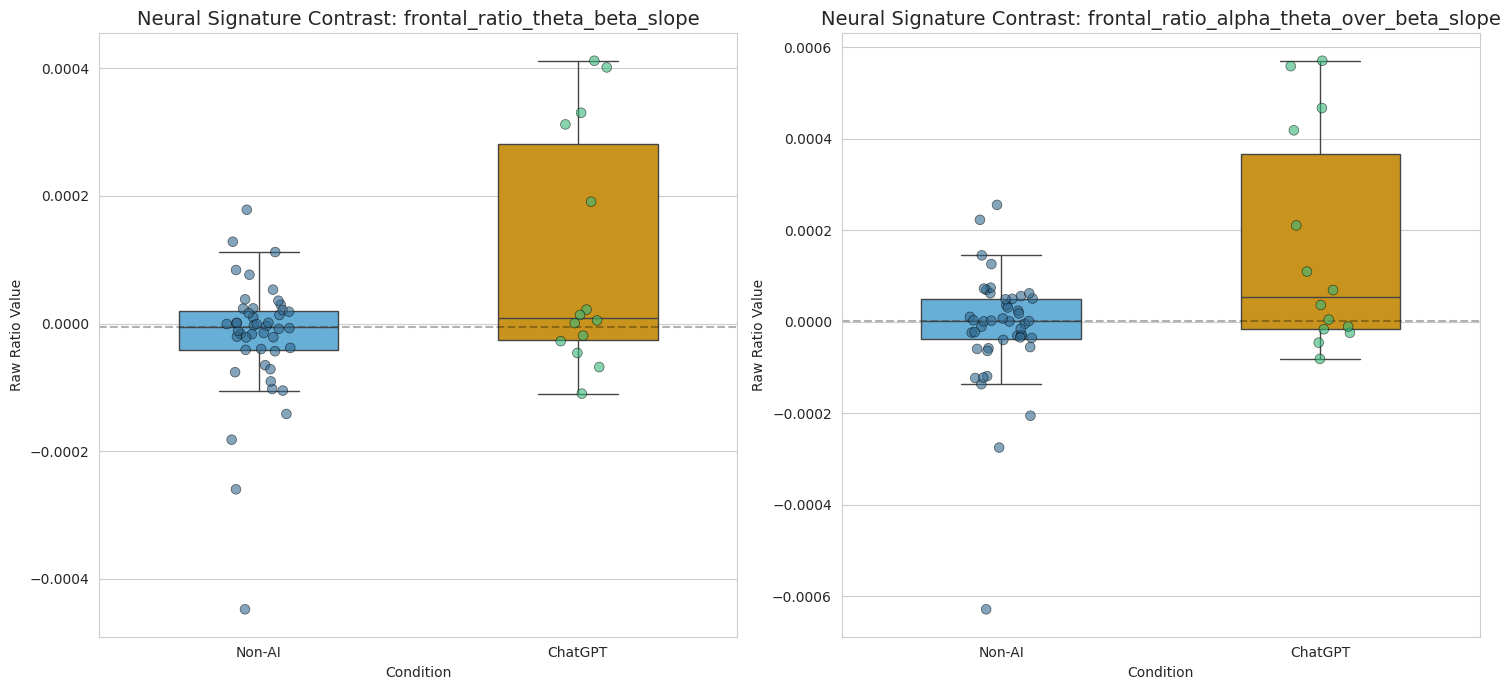

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup features
plot_top_2 = ['frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']

# 2. Simplify the Labels
data_plot = data.copy()
# Create a universal Binary Label for the legend
data_plot['Status'] = data_plot['label'].apply(lambda x: 'ChatGPT' if x == 'chatgpt' else 'Non-AI')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for i, feature in enumerate(plot_top_2):
    ax = axes[i]

    # BOXPLOT: Shows the distribution
    sns.boxplot(data=data_plot, x='Status', y=feature,
                palette={'ChatGPT': '#E69F00', 'Non-AI': '#56B4E9'},
                ax=ax, width=0.5, showfliers=False)

    # STRIPPLOT: Shows every individual person's data point
    # We use 'subject_id' for the hue so we can see the individual dots
    sns.stripplot(data=data_plot, x='Status', y=feature,
                  palette='viridis', alpha=0.6, ax=ax,
                  jitter=True, size=7, edgecolor='black', linewidth=0.5)

    ax.set_title(f'Neural Signature Contrast: {feature}', fontsize=14)
    ax.set_ylabel('Raw Ratio Value')
    ax.set_xlabel('Condition')

    # Add a horizontal line at the median of Non-AI to show the "Jump"
    median_val = data_plot[data_plot['Status'] == 'Non-AI'][feature].median()
    ax.axhline(median_val, color='black', linestyle='--', alpha=0.3, label='Baseline Median')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5741/2779190575.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_data.index.astype(str), y=display_data.values,
/tmp/ipykernel_5741/2779190575.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_data.index.astype(str), y=display_data.values,
/tmp/ipykernel_5741/2779190575.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_data.index.astype(str), y=display_data.values,
/tmp/ipykernel_5741/2779190575.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

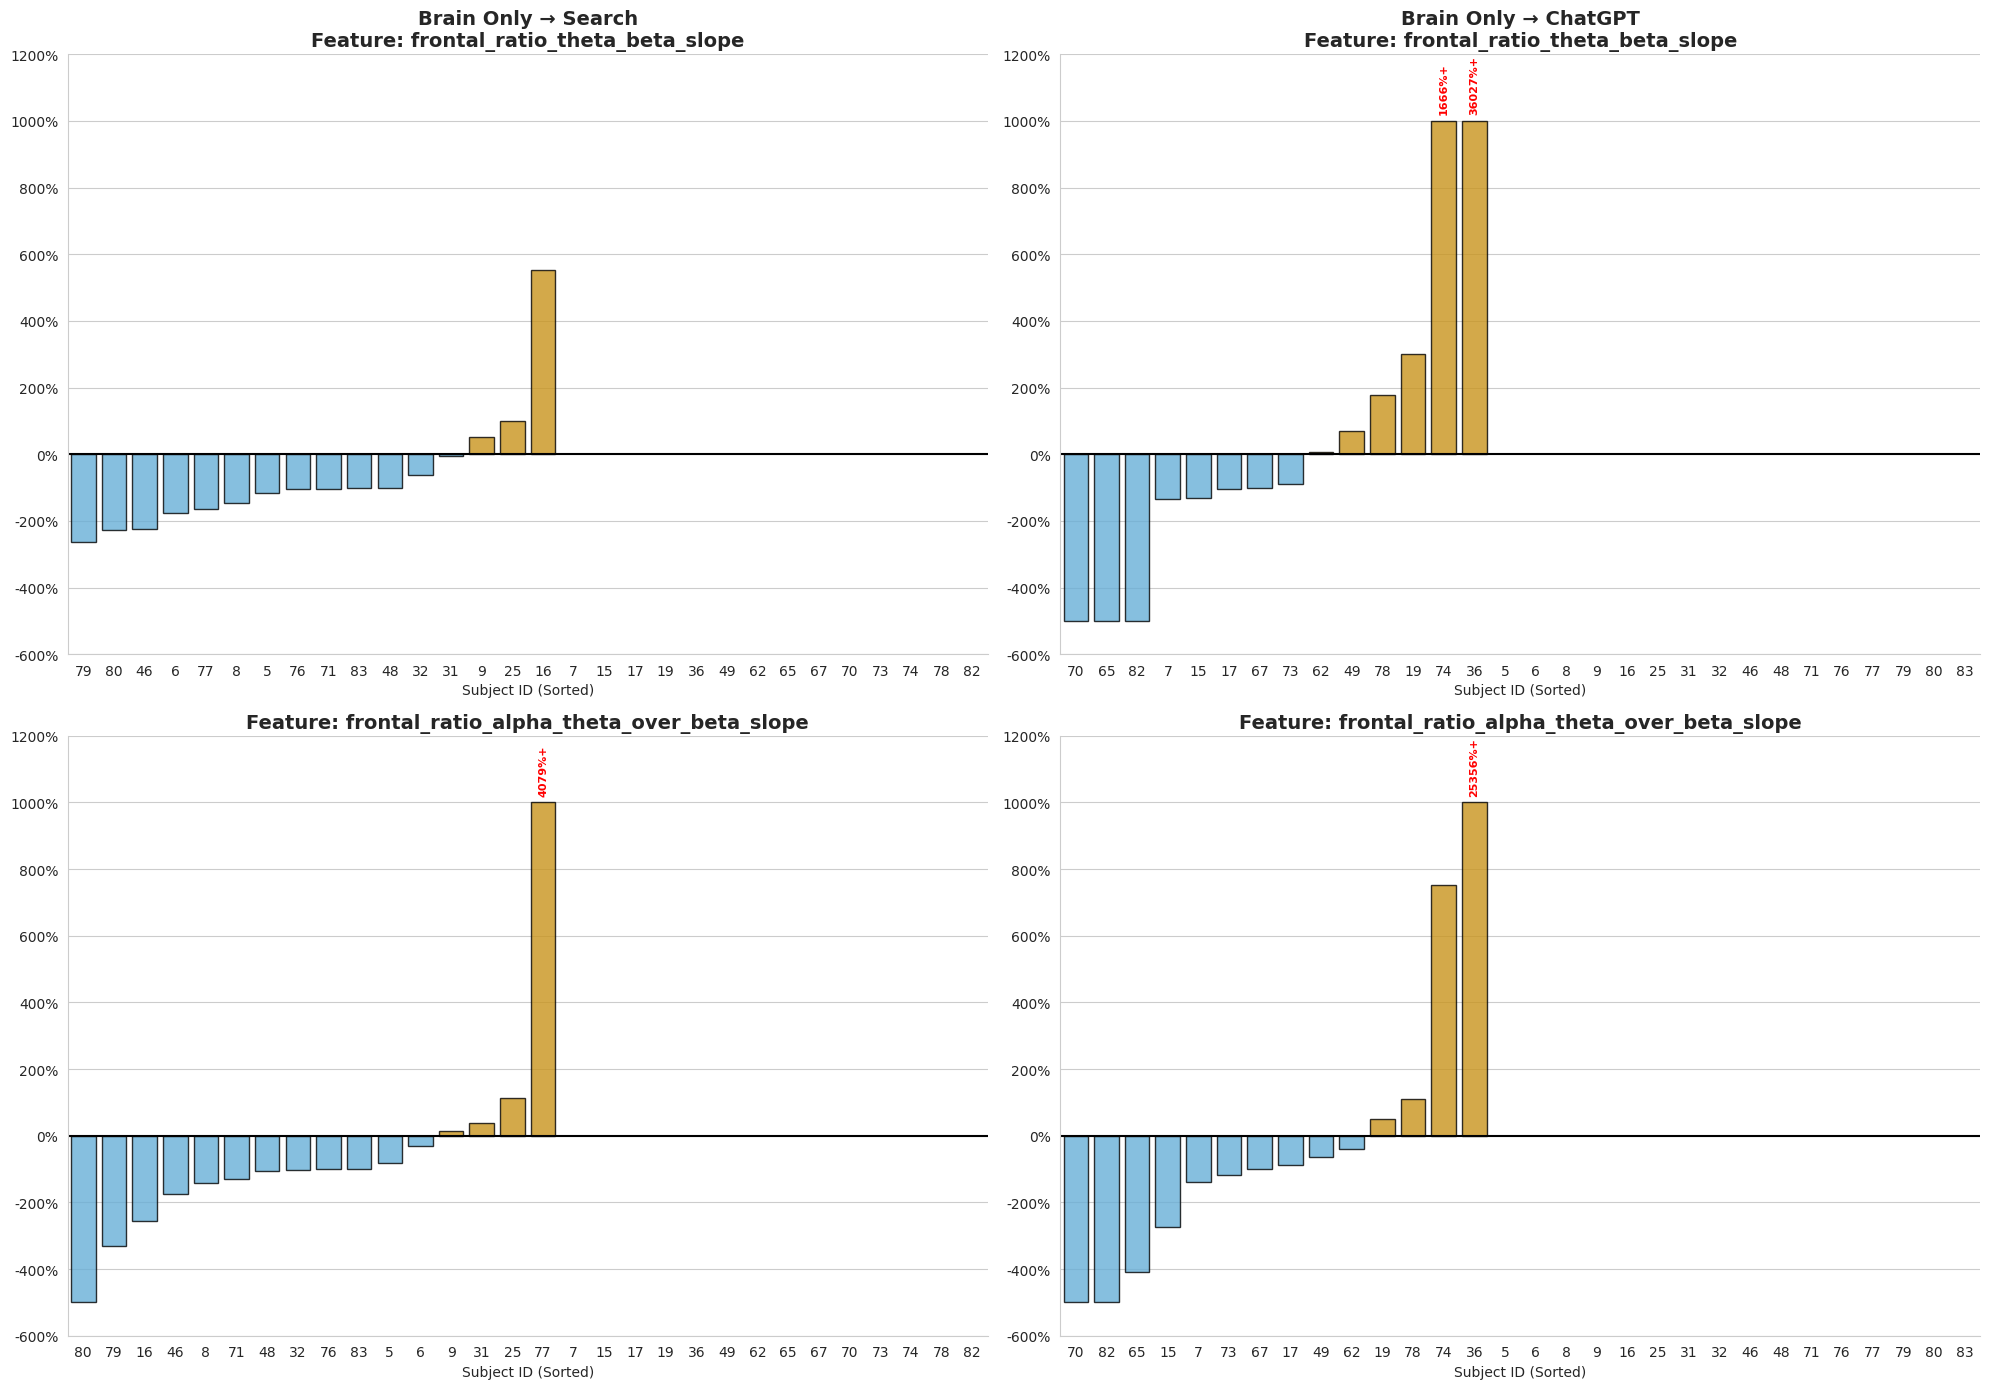

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. SETUP: Use the top_2_features identified by your RF/Tree
# These are likely: ['frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']
features_to_plot = top_2_features

# Prepare a clean summary for both features
summary_2 = data.groupby(['subject_id', 'label'])[features_to_plot].mean().unstack()

# 2. PLOTTING GRID (2 Features x 2 Conditions)
fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharey=False)

MAX_VIEW = 1000
MIN_VIEW = -500

for row_idx, feat in enumerate(features_to_plot):
    # Calculate Percent Change for this specific feature
    pct_search = ((summary_2[feat]['search'] - summary_2[feat]['brain_only']) / summary_2[feat]['brain_only']) * 100
    pct_chatgpt = ((summary_2[feat]['chatgpt'] - summary_2[feat]['brain_only']) / summary_2[feat]['brain_only']) * 100

    comparisons = [(pct_search, "Search"), (pct_chatgpt, "ChatGPT")]

    for col_idx, (series, tool_name) in enumerate(comparisons):
        ax = axes[row_idx, col_idx]

        # Sort and Clip for the "Clean Capped" look
        plot_data = series.sort_values()
        display_data = plot_data.clip(lower=MIN_VIEW, upper=MAX_VIEW)

        colors = ['#E69F00' if x > 0 else '#56B4E9' for x in display_data]

        sns.barplot(x=display_data.index.astype(str), y=display_data.values,
                    palette=colors, ax=ax, edgecolor='black', alpha=0.8)

        # Aesthetics
        ax.axhline(0, color='black', lw=1.5)
        ax.set_ylim(MIN_VIEW - 100, MAX_VIEW + 200)

        # Label the "1000%+" outliers
        for idx, val in enumerate(plot_data):
            if val > MAX_VIEW:
                ax.text(idx, MAX_VIEW + 20, f"{int(val)}%+", ha='center',
                        va='bottom', color='red', fontsize=8, fontweight='bold', rotation=90)

        # Title Logic
        if row_idx == 0:
            ax.set_title(f"Brain Only → {tool_name}\nFeature: {feat}", fontweight='bold', fontsize=14)
        else:
            ax.set_title(f"Feature: {feat}", fontweight='bold', fontsize=14)

        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
        ax.set_xlabel("Subject ID (Sorted)")
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5741/2122526675.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=task2_data, x='label', y=top_2[0], palette={'chatgpt': '#E69F00', 'search': '#56B4E9'})


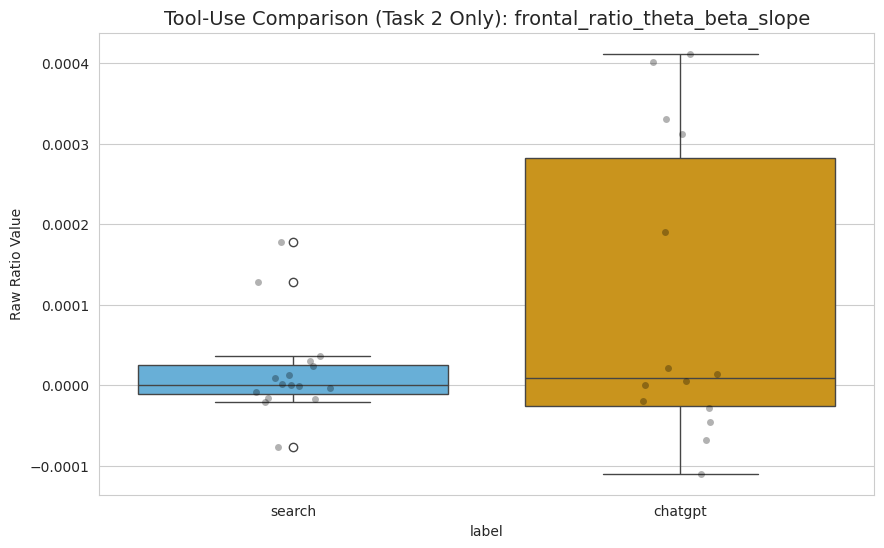

--------------------------------------------------
TASK 2 BETWEEN-SUBJECTS ACCURACY: 50.00%
--------------------------------------------------


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, classification_report

# 1. Isolate Task 2 Only
# Assuming Task 2 is identified by labels like 'chatgpt' and 'search'
task2_data = data[data['label'].isin(['chatgpt', 'search'])].copy()

# 2. Features and Target
top_2 = ['frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']
X = task2_data[top_2]
y = task2_data['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups = task2_data['subject_id']

# 3. GLOBAL SCALING (Between-Subjects Comparison)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Cross-Validation (Test on unseen people)
gkf = GroupKFold(n_splits=3) # Smaller split since Task 2 has fewer subjects
test_accs = []

for tr_idx, te_idx in gkf.split(X_scaled, y, groups=groups):
    rf = RandomForestClassifier(n_estimators=500, max_depth=3, class_weight='balanced', random_state=42)
    rf.fit(X_scaled[tr_idx], y.iloc[tr_idx])
    test_accs.append(rf.score(X_scaled[te_idx], y.iloc[te_idx]))

# --- VISUALIZATION: THE REAL GAP ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=task2_data, x='label', y=top_2[0], palette={'chatgpt': '#E69F00', 'search': '#56B4E9'})
sns.stripplot(data=task2_data, x='label', y=top_2[0], color='black', alpha=0.3)

plt.title(f'Tool-Use Comparison (Task 2 Only): {top_2[0]}', fontsize=14)
plt.ylabel('Raw Ratio Value')
plt.show()

print("-" * 50)
print(f"TASK 2 BETWEEN-SUBJECTS ACCURACY: {np.mean(test_accs)*100:.2f}%")
print("-" * 50)

           BLIND TEST: SUBJECT-NORMALIZED RESULTS           
Safe Test Accuracy: 87.50%
------------------------------------------------------------
              precision    recall  f1-score   support

      Non-AI       0.86      1.00      0.92         6
     ChatGPT       1.00      0.50      0.67         2

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8


Individual Predictions:
 Subject  Actual Predicted
       3 ChatGPT   ChatGPT
      27  Non-AI    Non-AI
      40 ChatGPT    Non-AI
      72  Non-AI    Non-AI
       3  Non-AI    Non-AI
      27  Non-AI    Non-AI
      40  Non-AI    Non-AI
      72  Non-AI    Non-AI


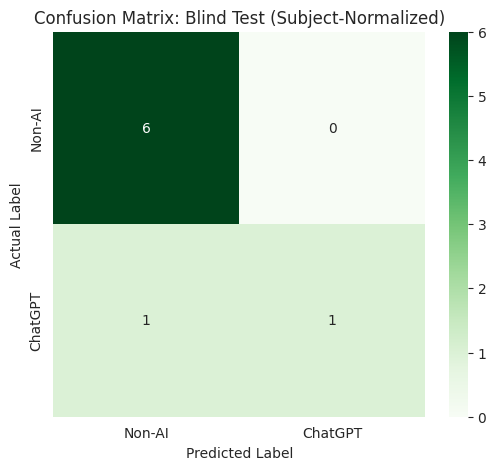

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Feature Selection (Using the same top_2 from your training)
top_2 = ['frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']

# 2. PREPARE TRAINING DATA (Knowledge Base)
y_train = data['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups_train = data['subject_id']
# Normalize per person in the training set
X_train_norm = data[top_2].groupby(groups_train).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 3. PREPARE SAFE DATA (Blind Test)
y_safe = the_safe['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups_safe = the_safe['subject_id']
# Normalize per person in the SAFE set (Crucial for directional shift)
X_safe_norm = the_safe[top_2].groupby(groups_safe).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 4. TRAIN FINAL MODEL & PREDICT
final_rf = RandomForestClassifier(n_estimators=500, max_depth=3, class_weight='balanced', random_state=42)
final_rf.fit(X_train_norm, y_train)

# Evaluate on Blind Test
safe_preds = final_rf.predict(X_safe_norm)
safe_acc = accuracy_score(y_safe, safe_preds)

# --- RESULTS OUTPUT ---
print("="*60)
print(f"{'BLIND TEST: SUBJECT-NORMALIZED RESULTS':^60}")
print("="*60)
print(f"Safe Test Accuracy: {safe_acc*100:.2f}%")
print("-" * 60)
print(classification_report(y_safe, safe_preds, target_names=['Non-AI', 'ChatGPT']))

# Individual Breakdown to see Subject 40
safe_results = pd.DataFrame({
    'Subject': groups_safe,
    'Actual': y_safe.map({1: 'ChatGPT', 0: 'Non-AI'}),
    'Predicted': pd.Series(safe_preds).map({1: 'ChatGPT', 0: 'Non-AI'}).values
})
print("\nIndividual Predictions:")
print(safe_results.to_string(index=False))

# Confusion Matrix for the Blind Test
cm = confusion_matrix(y_safe, safe_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-AI', 'ChatGPT'],
            yticklabels=['Non-AI', 'ChatGPT'])
plt.title('Confusion Matrix: Blind Test (Subject-Normalized)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

                      ACCURACY REPORT                       
TRAINING Accuracy (Original):  96.67%
TESTING Accuracy (Safe Blind): 87.50%
------------------------------------------------------------


/tmp/ipykernel_5741/1911513044.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_data.index.astype(str), y=display_data.values,
/tmp/ipykernel_5741/1911513044.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Value', data=box_data, ax=ax_box,
/tmp/ipykernel_5741/1911513044.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_data.index.astype(str), y=display_data.values,
/tmp/ipykernel_5741/1911513044.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

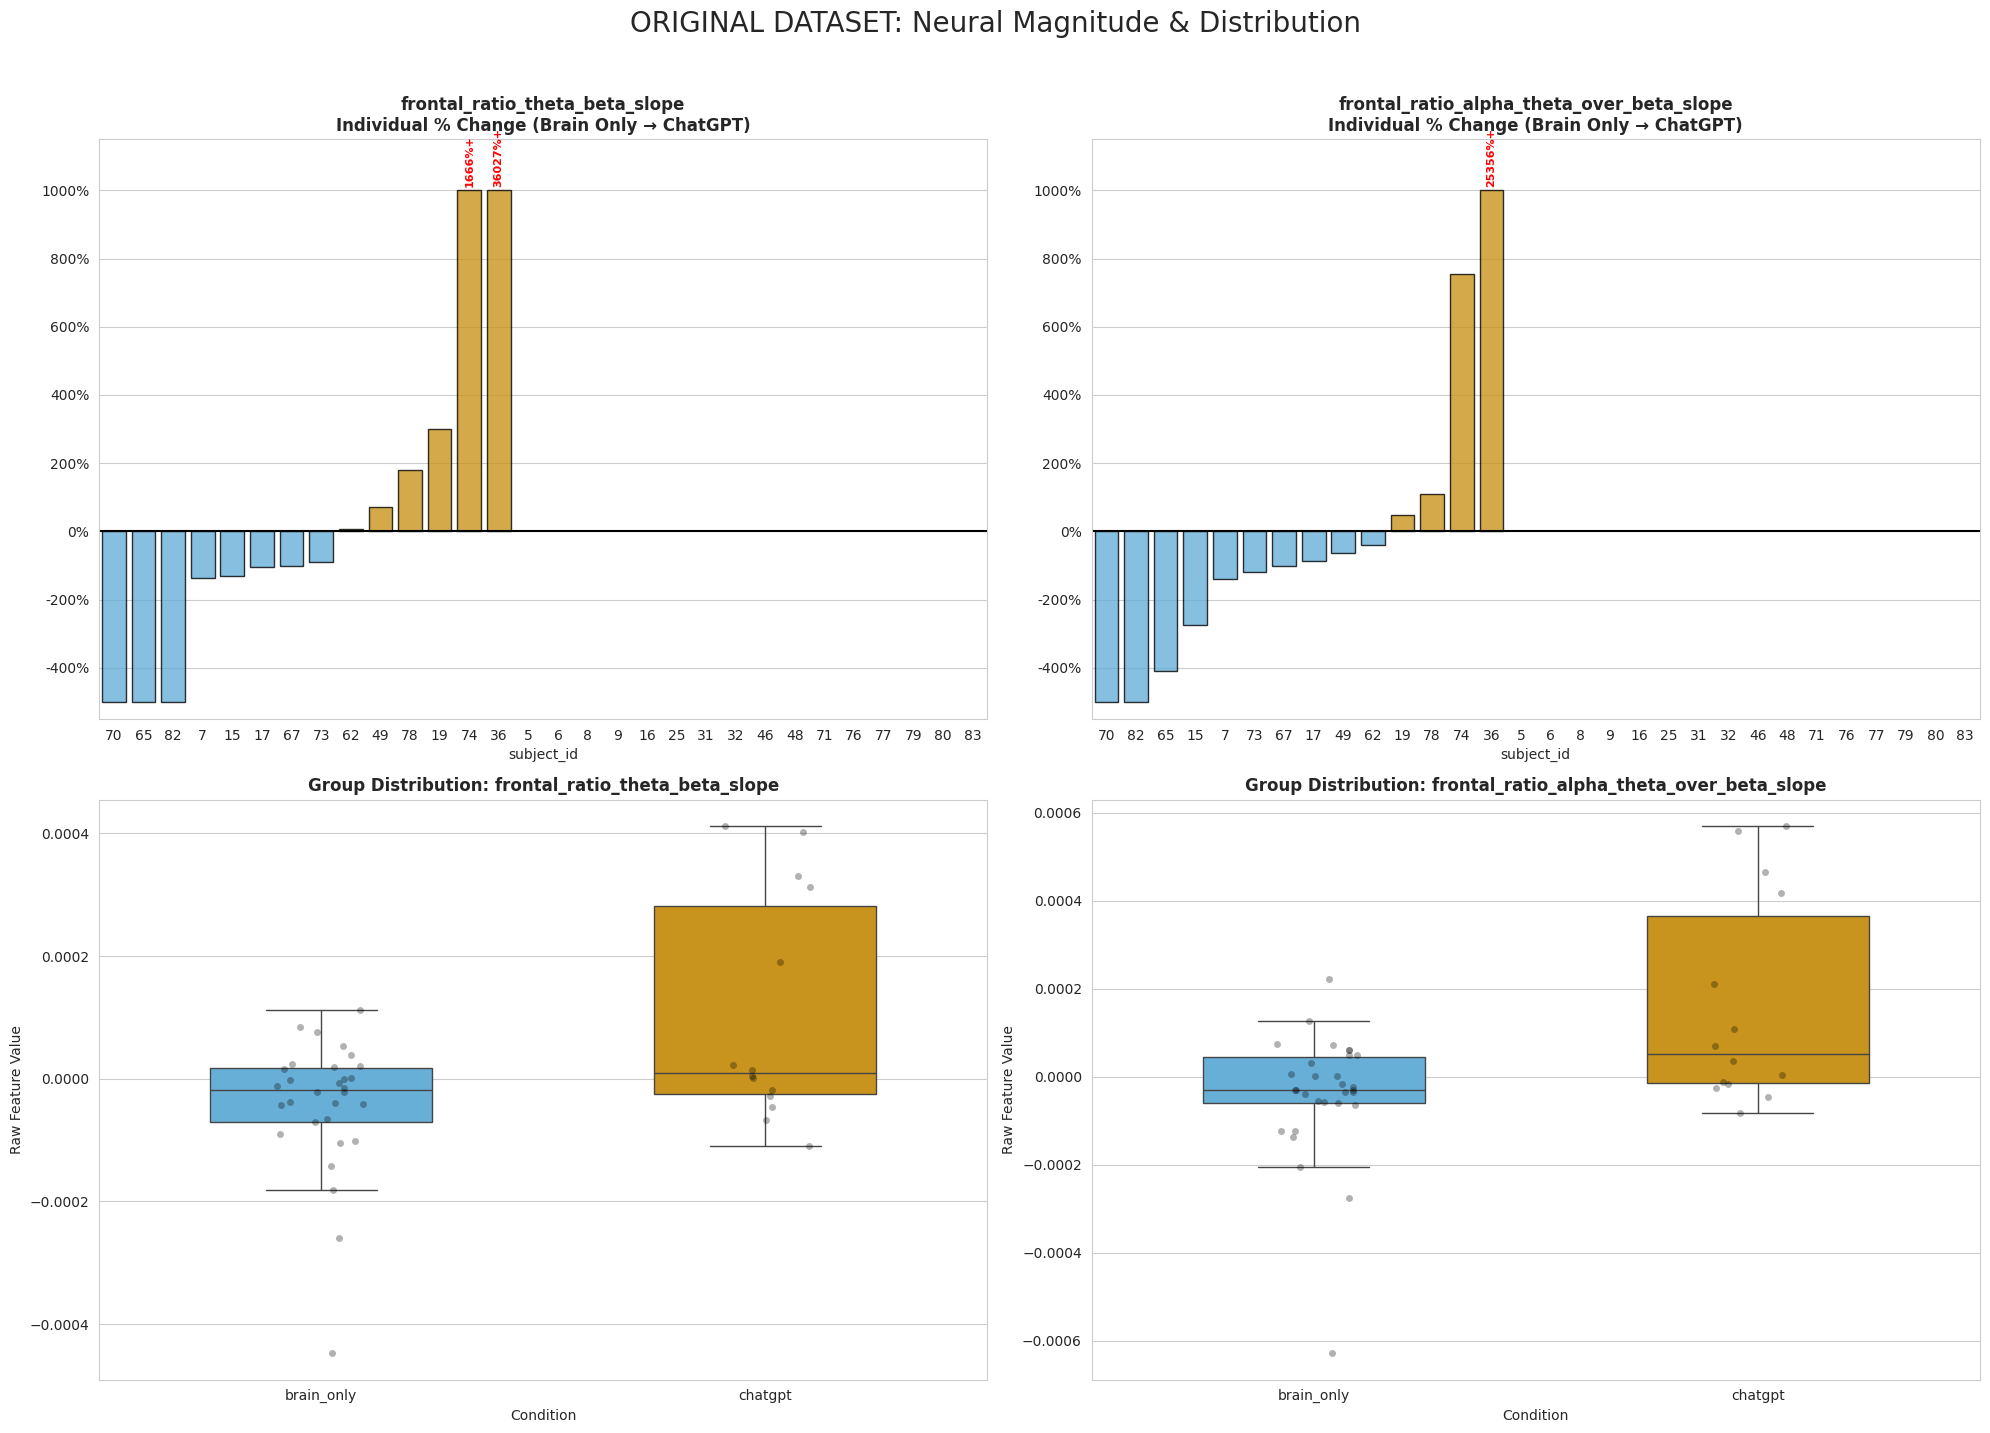

/tmp/ipykernel_5741/1911513044.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_data.index.astype(str), y=display_data.values,
/tmp/ipykernel_5741/1911513044.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Value', data=box_data, ax=ax_box,
/tmp/ipykernel_5741/1911513044.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_data.index.astype(str), y=display_data.values,
/tmp/ipykernel_5741/1911513044.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

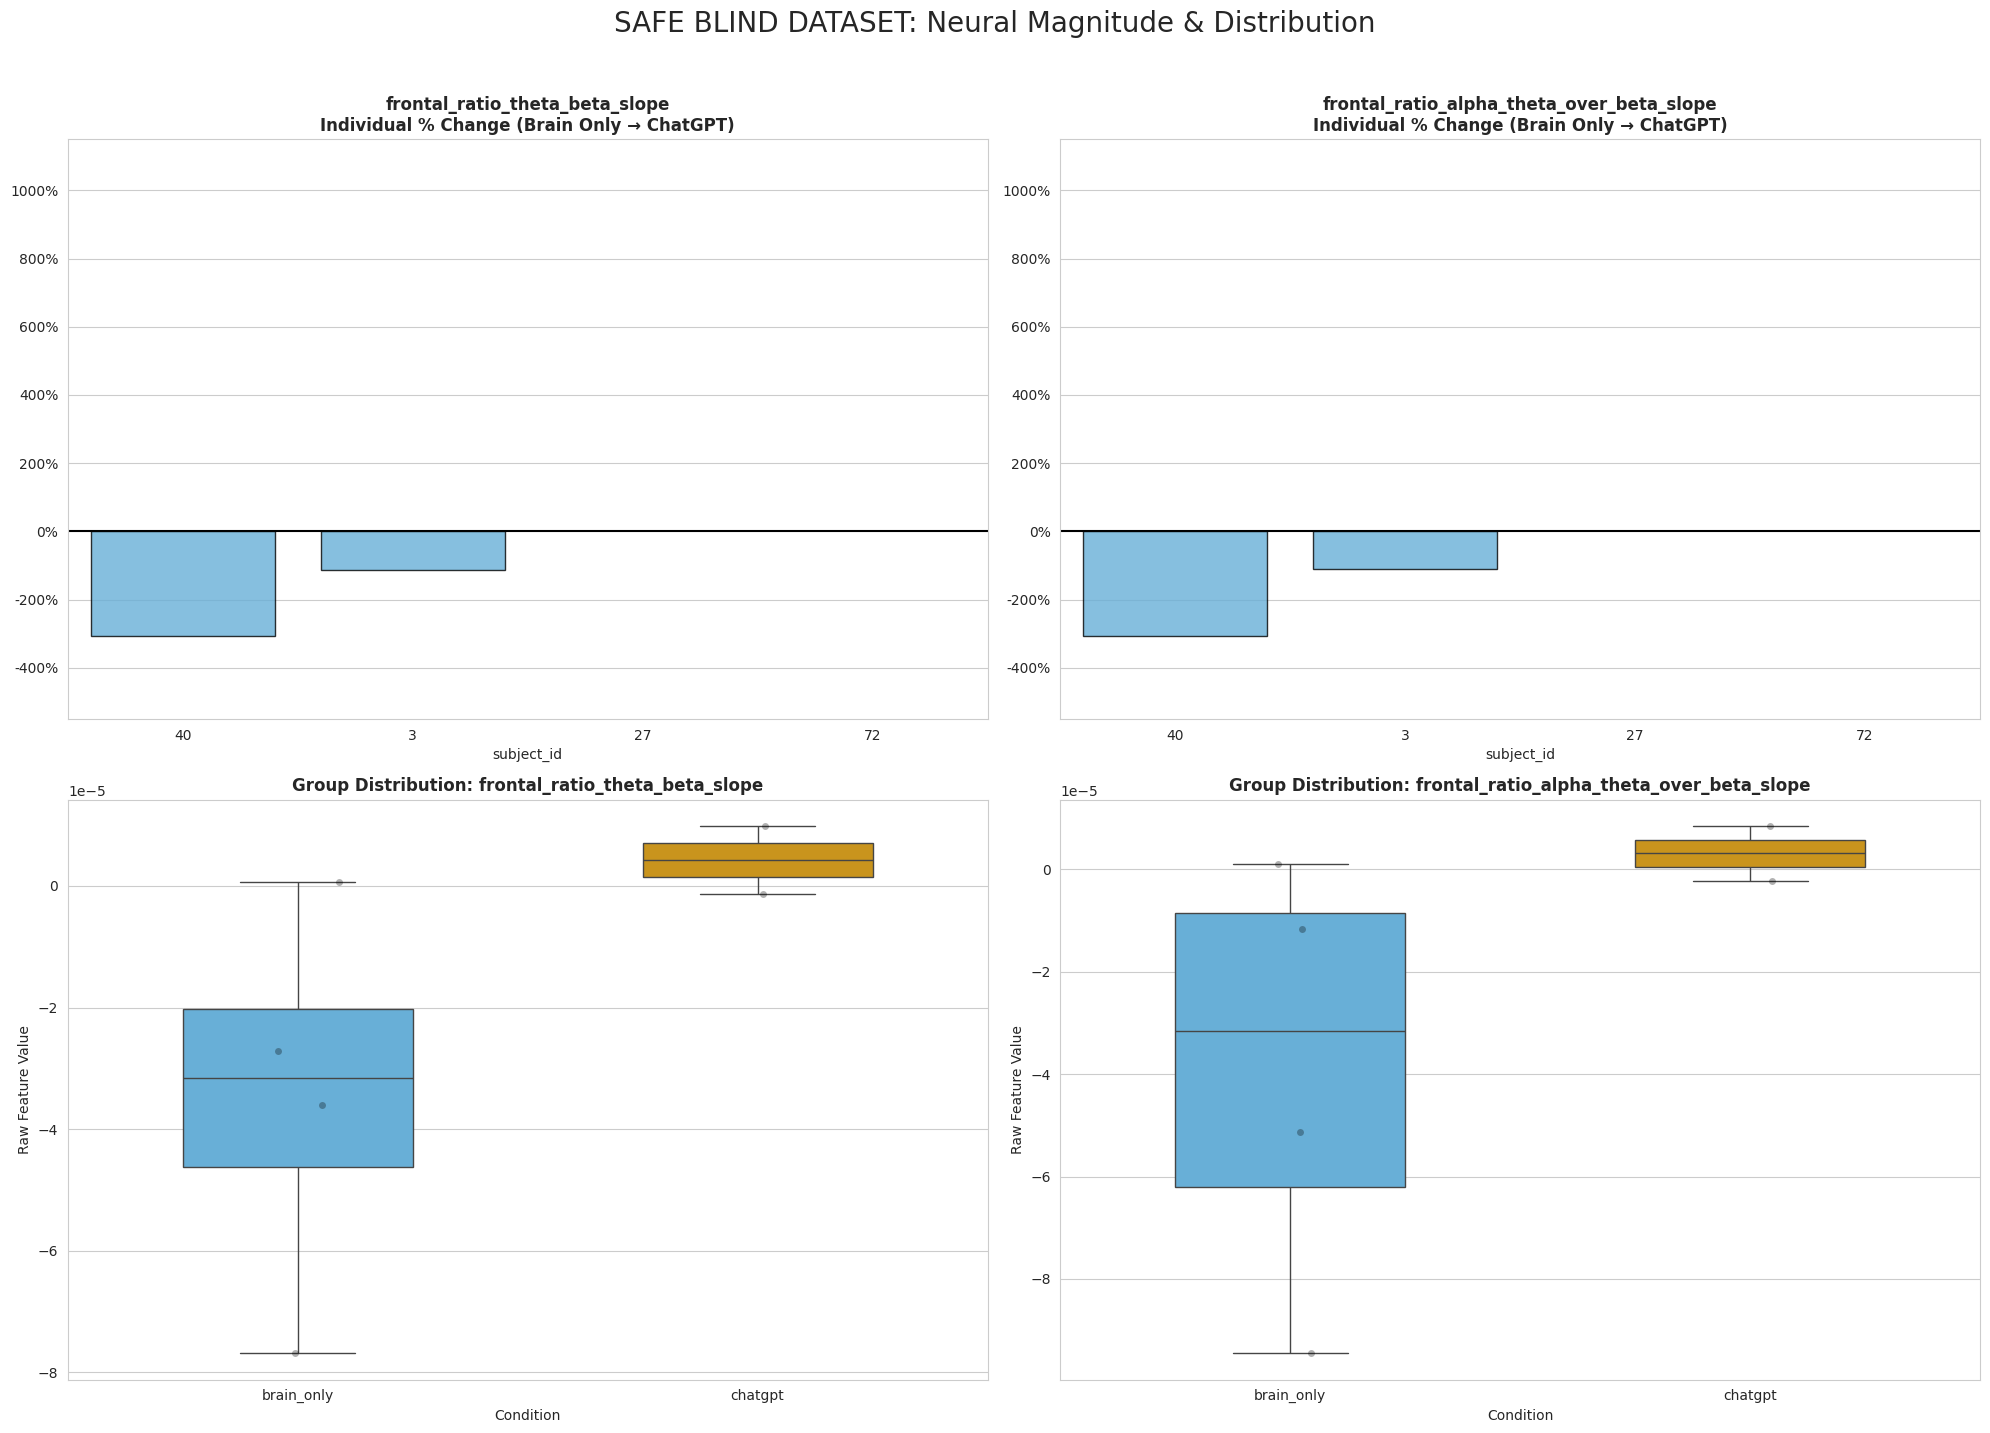

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. SETUP DATA & FEATURES
top_2 = ['frontal_ratio_theta_beta_slope', 'frontal_ratio_alpha_theta_over_beta_slope']

# Prepare Training Data
y_train = data['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups_train = data['subject_id']
X_train_norm = data[top_2].groupby(groups_train).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# Prepare Safe Data (Blind Test)
y_safe = the_safe['label'].apply(lambda x: 1 if x == 'chatgpt' else 0)
groups_safe = the_safe['subject_id']
X_safe_norm = the_safe[top_2].groupby(groups_safe).transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# 2. TRAIN & EVALUATE
final_rf = RandomForestClassifier(n_estimators=500, max_depth=3, class_weight='balanced', random_state=42)
final_rf.fit(X_train_norm, y_train)

# Calculate Accuracies
train_acc = accuracy_score(y_train, final_rf.predict(X_train_norm))
safe_preds = final_rf.predict(X_safe_norm)
safe_acc = accuracy_score(y_safe, safe_preds)

# --- ACCURACY OUTPUT ---
print("="*60)
print(f"{'ACCURACY REPORT':^60}")
print("="*60)
print(f"TRAINING Accuracy (Original):  {train_acc*100:.2f}%")
print(f"TESTING Accuracy (Safe Blind): {safe_acc*100:.2f}%")
print("-" * 60)

# 3. VISUALIZATION FUNCTION (STAIRCASE + BOXPLOT)
def plot_comprehensive_results(df_input, title_prefix):
    # Prepare summary
    summary = df_input.groupby(['subject_id', 'label'])[top_2].mean().unstack()

    # Create a 2x2 grid: Top row = Staircases, Bottom row = Boxplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    MAX_VIEW, MIN_VIEW = 1000, -500

    for i, feat in enumerate(top_2):
        # --- A. STAIRCASE PLOT (Top Row) ---
        ax_bar = axes[0, i]
        pct_change = ((summary[feat]['chatgpt'] - summary[feat]['brain_only']) / summary[feat]['brain_only']) * 100
        plot_data = pct_change.sort_values()

        display_data = plot_data.clip(lower=MIN_VIEW, upper=MAX_VIEW)
        colors = ['#E69F00' if x > 0 else '#56B4E9' for x in display_data]

        sns.barplot(x=display_data.index.astype(str), y=display_data.values,
                    palette=colors, ax=ax_bar, edgecolor='black', alpha=0.8)

        ax_bar.axhline(0, color='black', lw=1.5)
        ax_bar.set_ylim(MIN_VIEW - 50, MAX_VIEW + 150)

        # Label Outliers
        for idx, val in enumerate(plot_data):
            if val > MAX_VIEW:
                ax_bar.text(idx, MAX_VIEW + 10, f"{int(val)}%+", ha='center', va='bottom',
                            color='red', fontsize=8, fontweight='bold', rotation=90)

        ax_bar.set_title(f"{feat}\nIndividual % Change (Brain Only → ChatGPT)", fontweight='bold')
        ax_bar.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))

        # --- B. BOXPLOT (Bottom Row) ---
        ax_box = axes[1, i]

        # Melt the summary data for the boxplot
        box_data = summary[feat][['brain_only', 'chatgpt']].melt(var_name='Condition', value_name='Value')

        sns.boxplot(x='Condition', y='Value', data=box_data, ax=ax_box,
                    palette=['#56B4E9', '#E69F00'], width=0.5, showfliers=False)
        sns.stripplot(x='Condition', y='Value', data=box_data, ax=ax_box,
                      color='black', alpha=0.3, jitter=True)

        ax_box.set_title(f"Group Distribution: {feat}", fontweight='bold')
        ax_box.set_ylabel("Raw Feature Value")

    plt.suptitle(f"{title_prefix}: Neural Magnitude & Distribution", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# Run for both sets
plot_comprehensive_results(data, "ORIGINAL DATASET")
plot_comprehensive_results(the_safe, "SAFE BLIND DATASET")